# INTRODUCCION

# ETAPA 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Funciones

### weighted percentiles

In [3]:
def weighted_percentiles(data, value, weight, percentiles):
    """
    Compute weighted percentiles.

    Parameters
    ----------
    data : DataFrame
    value : str
        Variable whose percentiles are desired.
    weight : str
        Survey weight.
    percentiles : iterable
        Percentiles between 0 and 1.

    Returns
    -------
    dict
    """

    df = data[[value, weight]].sort_values(value).reset_index(drop=True)

    cumsum = df[weight].cumsum()
    total = cumsum.iloc[-1]

    out = {}

    for p in percentiles:
        target = p * total
        idx = cumsum.searchsorted(target)
        out[p] = df.iloc[idx][value]

    return out

### residual plot

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

def residual_plot(data, response, weight = None, log = False):
    # ============================
    # Prepare data
    # ============================


    X = data.drop(columns=[response])
    y = data[response]



    # Remove weight from predictors if present
    if weight:
        X = X.drop(columns=[weight])
        w = data[weight]
    else:
        w = None


    # Add intercept
    X = sm.add_constant(X)

    # ============================
    # Fit weighted linear regression
    # ============================

    model = sm.WLS(y, X, weights=w)
    results = model.fit()

    print(results.summary())

    # ============================
    # Diagnostics
    # ============================

    fitted = results.fittedvalues
    residuals = results.resid
    abs_residuals = np.abs(residuals)

    # ----------------------------
    # Histogram of residuals
    # ----------------------------

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=40)
    plt.title("Residual Histogram")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    # ----------------------------
    # Residuals vs Fitted
    # ----------------------------

    plt.figure(figsize=(6,4))

    plt.scatter(fitted, residuals, s=8, alpha=0.4)

    # LOESS curve
    loess = lowess(residuals, fitted, frac=0.3)
    plt.plot(loess[:,0], loess[:,1], color="red", linewidth=2)

    plt.axhline(0, color="black", linestyle="--")

    plt.title("Residuals vs Fitted")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    plt.show()

    # ----------------------------
    # Absolute Residuals vs Fitted
    # ----------------------------

    plt.figure(figsize=(6,4))

    plt.scatter(fitted, abs_residuals, s=8, alpha=0.4)

    # LOESS curve
    loess = lowess(abs_residuals, fitted, frac=0.3)
    plt.plot(loess[:,0], loess[:,1], color="red", linewidth=2)

    plt.title("Absolute Residuals vs Fitted")
    plt.xlabel("Fitted values")
    plt.ylabel("|Residual|")
    plt.grid(alpha=0.3)
    plt.show()

### Wighted Histogram

### valididy check

In [5]:

def weighted_histogram(data, response="KWH", weight=None, bins=40, transform="none"):
    """
    Crea un histograma de la variable respuesta ponderado por los pesos.

    INPUT:
        data : pandas.DataFrame
            DataFrame que contiene la variable respuesta.

        response : str
            Nombre de la variable respuesta.

        bins : int
            Cantidad de intervalos del histograma.

    OUTPUT:
        Muestra un histograma de la variable respuesta.
    """

    plt.figure(figsize=(8, 5))

    # Select the response variable
    x = data[response].dropna()

    # Initialize weights for the histogram
    hist_weights = None

    if weight:
        # Ensure 'weight' column exists and is numeric
        if weight not in data.columns:
            raise ValueError(f"Weight column '{weight}' not found in data.")

        # Align response and weight data by dropping NaNs from both simultaneously
        temp_df = data[[response, weight]].dropna()
        x = temp_df[response]
        hist_weights = temp_df[weight].astype(float) # Weights should be float

    if transform == "log":
        x = np.log10(x)
        xlabel = f"log10( {response} )"
        title = f"Histograma de log {response} "
    elif transform == "exp10":
        x = 10**x
        xlabel = f"10^{response}"
        title = f"Histograma de 10^{response}"
    else:
        xlabel = response
        title = f"Histograma de {response}"

    plt.ylabel("Frecuencia")

    # Use the 'weights' parameter for a statistically correct weighted histogram
    plt.hist(
        x,
        bins=bins,
        edgecolor="black",
        weights=hist_weights # Pass the weights here
    )
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [6]:
def validity_check(data,
                   sparse_threshold=0.99,
                   dominant_threshold=0.70,
                   contiguous_threshold=0.90,
                   corr_threshold=0.70):

    nan_vars = []
    constant_vars = []
    sparse_vars = []
    dominant_vars = []
    contiguous_vars = []
    negative_vars = []

    # ======================================================
    # Variable-by-variable checks
    # ======================================================

    for col in data.columns:

        s = data[col]

        # NaN
        if s.isna().any():
            nan_vars.append(col)

        # Negative values
        if pd.api.types.is_numeric_dtype(s):
            if (s < 0).any():
                negative_vars.append(col)

        # Constant
        if s.nunique(dropna=True) == 1:
            constant_vars.append(col)

        # Sparse (>99% same value)
        freq = s.value_counts(normalize=True, dropna=False)

        if len(freq) > 0:

            if freq.iloc[0] >= sparse_threshold:
                sparse_vars.append(col)

            # Only for variables with >=3 values
            if s.nunique(dropna=True) >= 3:

                # 70% same value
                if freq.iloc[0] >= dominant_threshold:
                    dominant_vars.append(col)

                # 90% in two contiguous values
                vals = s.dropna()

                if pd.api.types.is_numeric_dtype(vals):

                    uniques = np.sort(vals.unique())

                    for i in range(len(uniques)-1):

                        if uniques[i+1] - uniques[i] == 1:

                            prop = (
                                vals.isin([uniques[i], uniques[i+1]])
                                .mean()
                            )

                            if prop >= contiguous_threshold:
                                contiguous_vars.append(col)
                                break

    # ======================================================
    # Correlations
    # ======================================================

    numeric = data.select_dtypes(include=np.number)

    corr = numeric.corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={
            "level_0":"Variable 1",
            "level_1":"Variable 2",
            0:"Correlación"
        })
    )

    high_corr = (
        pairs[pairs["Correlación"] >= corr_threshold]
        .sort_values("Correlación", ascending=False)
    )

    corr_vars = set(high_corr["Variable 1"]).union(high_corr["Variable 2"])

    # ======================================================
    # Report
    # ======================================================
    print("="*70)

    print(f"{data.shape[1]} variables en el dataset.")

    print("="*70)

    print(f"{data.shape[0]} observaciones en el dataset.")


    print("="*70)

    print(f"{len(nan_vars)} variables contienen NA.")
    print(nan_vars)

    print()

    print(f"{len(negative_vars)} variables contienen valores negativos.")
    print(negative_vars)

    print()

    print(f"{len(constant_vars)} variables son constantes.")
    print(constant_vars)

    print()

    print(f"{len(sparse_vars)} variables tienen más del {100*sparse_threshold//1}% del mismo valor.")
    print(sparse_vars)

    print()

    print(f"{len(dominant_vars)} variables tienen más del {100*dominant_threshold//1}% del mismo valor.")
    print(dominant_vars)

    print()

    print(f"{len(contiguous_vars)} variables tienen más del {100*contiguous_threshold//1}% concentrado en dos valores consecutivos.")
    print(contiguous_vars)

    print()

    print(f"{len(corr_vars)} variables tienen al menos una correlación superior a {corr_threshold:.2f}.")

    print("\nTop 10 pares más correlacionados:\n")

    print(high_corr.head(10))

    print("="*70)

    return {
        "NA": nan_vars,
        "Negativos": negative_vars,
        "Constantes": constant_vars,
        "Dispersas": sparse_vars,
        "Dominantes": dominant_vars,
        "Contiguas": contiguous_vars,
        "Correlaciones": high_corr
    }

### Comboplot

In [7]:

def weighted_median(values, weights):
    """Weighted median."""
    values = np.asarray(values)
    weights = np.asarray(weights)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cum_weights = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[cum_weights >= cutoff][0]


def combo_plot(data, response, x, weight=None, type="auto", bins=30, log=False):

    """
    Crea un histograma (o gráfico de barras) de la variable x,
    además le superpone un gráfico loess (o de línea de la mediana) de
    la respuesta.
    Si se utilizan los pesos (weights) estos se aplican a ambas variables.

    INPUT
    -----
    data : pandas DataFrame
    response : variable respuesta
    x : variable explicativa (para el histograma)
    weight : peso de las observaciones (opcional)
    type : "auto" para elegir automáticamente, "continuous" para histograma+loess, "discrete" para barras+línea.
    bins : número de columnas en el histograma.

    OUTPUT
    ------
    Muestra los gráficos
    """

    df = data[[response, x]].copy()
    df = df.dropna()

    if log:
        df[response] = np.log10(df[response])

    if weight is None:
        df["_weight"] = 1.0
    else:
        df["_weight"] = data[weight]

    df = df.dropna()

    if type == "auto":
        if df[x].nunique() > 50:
            type = "continuous"
        else:
            type = "discrete"

    fig, ax1 = plt.subplots(figsize=(10,5))

    ############################################################
    # CONTINUOUS
    ############################################################

    if type == "continuous":

        # histogram
        counts, edges = np.histogram(
            df[x],
            bins=bins,
            weights=df["_weight"]
        )

        centers = (edges[:-1] + edges[1:]) / 2
        widths = np.diff(edges)

        ax1.bar(
            centers,
            counts,
            width=widths,
            color="lightgray",
            edgecolor="black",
            alpha=.6
        )

        ax1.set_ylabel("Weighted Frequency")

        # weighted median per bin
        medians = []

        for i in range(len(edges)-1):

            if i == len(edges)-2:
                mask = (df[x] >= edges[i]) & (df[x] <= edges[i+1])
            else:
                mask = (df[x] >= edges[i]) & (df[x] < edges[i+1])

            if mask.sum() == 0:
                medians.append(np.nan)
            else:
                medians.append(
                    weighted_median(
                        df.loc[mask, response],
                        df.loc[mask, "_weight"]
                    )
                )

        ax2 = ax1.twinx()

        centers = np.array(centers)
        medians = np.array(medians)


        ax2.plot(
            centers[~np.isnan(medians)],
            medians[~np.isnan(medians)],
            color="red",
            linewidth=2,
        )

        ax2.set_ylabel(f"Median {response}")

    ############################################################
    # DISCRETE
    ############################################################

    elif type == "discrete":

        summary = []

        for level, group in df.groupby(x):

            summary.append({
                x: level,
                "count": group["_weight"].sum(),
                "median": weighted_median(
                    group[response],
                    group["_weight"]
                )
            })

        summary = pd.DataFrame(summary)
        summary = summary.sort_values(x)

        # Use the actual numerical values for positioning the bars and median line
        x_values_for_plot = summary[x].values

        ax1.bar(
            x_values_for_plot, # Use actual numerical values for positions
            summary["count"],
            color="lightgray",
            edgecolor="black",
            alpha=.6
        )

        ax1.set_ylabel("Weighted Frequency")
        # Set ticks to the actual discrete values and labels to their string representation
        ax1.set_xticks(x_values_for_plot)
        ax1.set_xticklabels(summary[x].astype(str), rotation=45, ha="right")


        ax2 = ax1.twinx()

        ax2.plot(
            x_values_for_plot, # Use actual numerical values for median plot too
            summary["median"],
            color="red",
            marker="o",
            linewidth=2
        )

        ax2.set_ylabel(f"Median {response}")


    if log:
      plt.title(f"Log( {response} ) vs {x}")
    else:
      plt.title(f"{response} vs {x}")
    plt.tight_layout()
    plt.show()

### linear regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def linear_regression(
    train_data,
    test_data,
    response,
    weight,
    return_model=False,
):
    """
    Ajusta una regresión lineal ponderada y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame
            Conjunto de entrenamiento.

        test_data : pandas.DataFrame
            Conjunto de prueba.

        response : str
            Variable respuesta.

        weight : str
            Variable de ponderación.

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = LinearRegression()

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test
    )

    if return_model:
        return model
    else:
        return r2


### lightgbm

In [9]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score


def lightgbm(
    train_data,
    test_data,
    response,
    weight,
    learning_rate
):
    """
    Ajusta un LightGBM ponderado y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame

        test_data : pandas.DataFrame

        response : str

        weight : str

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=learning_rate,
        max_depth=7,
        num_leaves=64,
        min_child_samples=35,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1,
        random_state=123,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train,
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test,
    )

    return r2



def lightgbm_001(
    train_data,
    test_data,
    response,
    weight,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.001,
    )

def lightgbm_01(
    train_data,
    test_data,
    response,
    weight,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.01,
    )


def lightgbm_05(
    train_data,
    test_data,
    response,
    weight,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.05,
    )



def lightgbm_10(
    train_data,
    test_data,
    response,
    weight,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.10,
    )

### random forest

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def random_forest(
    train_data,
    test_data,
    response,
    weight,
    max_depth,
):
    """
    Ajusta un Random Forest ponderado y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame

        test_data : pandas.DataFrame

        response : str

        weight : str

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=max_depth,
        min_samples_leaf=35,
        random_state=123,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test
    )

    return r2


def random_forest_6(
    train_data,
    test_data,
    response,
    weight
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=6)

def random_forest_8(
    train_data,
    test_data,
    response,
    weight
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=8)

def random_forest_10(
    train_data,
    test_data,
    response,
    weight
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=10)

### cross validation

In [11]:
from sklearn.model_selection import KFold

def cross_validation(
    data,
    kfolds,
    seed,
    list_of_models,
    response,
    weight,
):
    """
    Performs k-fold cross-validation on one or more prediction models.

    Each model must be a function with the following syntax:

        model(train_data, test_data, response, weight)

    and must return the weighted R² on the test dataset.

    INPUT:
        data : pandas.DataFrame

        kfolds : int

        seed : int

        list_of_models : dict
            Dictionary of the form

                {
                    "Linear": linear_regression,
                    "RF": random_forest,
                    ...
                }

        response : str

        weight : str

    OUTPUT:
        pandas.DataFrame containing the median R² for each model.
    """

    cv = KFold(
        n_splits=kfolds,
        shuffle=True,
        random_state=seed
    )

    results = {name: [] for name in list_of_models}

    for train_idx, test_idx in cv.split(data):

        train_data = data.iloc[train_idx]
        test_data = data.iloc[test_idx]

        for name, model in list_of_models.items():

            r2 = model(
                train_data=train_data,
                test_data=test_data,
                response=response,
                weight=weight,
            )

            results[name].append(r2)

    summary = pd.DataFrame({
        "Model": results.keys(),
        "Median_R2": [np.median(v) for v in results.values()]
    })

    return summary.sort_values(
        "Median_R2",
        ascending=False
    ).reset_index(drop=True)

### get_model

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pprint

def get_model(
    df: pd.DataFrame,
    y_col: str,
    x_cols: list[str],
    weight_col: str,
    normalize_weights: bool = True,
    print_dict: bool = True
) -> dict:
    """
    Fit weighted linear regression and return a reusable model_info dictionary.

    By default the expansion factors are normalized (mean weight = 1)
    so that the residual scale is on the original scale of y.
    """
    y = df[y_col].values
    X = sm.add_constant(df[x_cols], prepend=True)          # column name = "const"
    weights = df[weight_col].values.astype(float)

    if normalize_weights:
        weights = weights / weights.mean()                 # mean(weight) = 1

    model = sm.WLS(y, X, weights=weights).fit()

    # Unweighted RMSE (always on the original scale of y) – useful for reference
    unweighted_rmse = float(np.sqrt(np.mean(model.resid ** 2)))

    model_info = {
        "coefs": model.params.to_dict(),                   # "const", ...
        "cov": model.cov_params().values,                  # full covariance matrix
        "df_resid": int(model.df_resid),
        "scale": float(np.sqrt(model.scale)),              # residual SE (now on y-scale)
        "unweighted_rmse": unweighted_rmse,
        "nobs": int(model.nobs),
        "rsquared": float(model.rsquared),
        "weights_normalized": normalize_weights,
    }

    if print_dict:
        print("model_info = ")
        pprint.pprint(model_info, width=120, sort_dicts=False)
        print()

    return model_info

# ETAPA 1: Limpieza de la base

## IMPORTA LA BASE

In [13]:
# Carga dataset
url = "https://raw.githubusercontent.com/No-Country-simulation/Team45-G9/data_science/data_science/bases/CHILE/bbdd_estudio_caracterizacion_residencial_2018_1.xlsx"
data = pd.read_excel(url)


# Preview
print(data.head())


   Folio  Clasificación_socioeconómica   F1   F2  P1  P2  P3_A  P3_B  P4  P5  \
0      1                             1  1.0  2.0   1 NaN   NaN   NaN   2   2   
1      2                             1  2.0  2.0   1 NaN   NaN   NaN   2   3   
2      3                             2  1.0  2.0   1 NaN   NaN   NaN   2   4   
3      4                             3  1.0  2.0   1 NaN   NaN   NaN   2   2   
4      5                             1  1.0  2.0   1 NaN   NaN   NaN   2   2   

   ...  Aspiradora Electricidad  Computador Electricidad  TV Electricidad  \
0  ...             63776.272095             26262.741791    203063.650351   
1  ...                 0.000000             34465.242092    275189.721288   
2  ...             54846.558931             84695.743888    134703.148734   
3  ...                 0.000000              3936.971598    348538.183457   
4  ...                 0.000000             16282.767975    385787.695972   

   Juegos Electricidad Stand by Electricidad  A/C Electr

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Columns: 551 entries, Folio to Otros Electricidad
dtypes: float64(418), int64(98), object(35)
memory usage: 14.7+ MB


In [ ]:
data.columns

Index(['Folio', 'Clasificación_socioeconómica', 'F1', 'F2', 'P1', 'P2', 'P3_A',
       'P3_B', 'P4', 'P5',
       ...
       'Aspiradora Electricidad', 'Computador Electricidad', 'TV Electricidad',
       'Juegos Electricidad', 'Stand by Electricidad', 'A/C Electricidad',
       'Cafetera Electricidad', 'Bomba de riego Electricidad',
       'Piscina Electricidad', 'Otros Electricidad'],
      dtype='object', length=551)

## RECODIFICACIÓN Y TRANSFORMACIÓN

Se seleccionan las variables utilizadas para el modelo de EEUU. Sin embargo existen algunos problemas para igualar las bases:

| Variable  |  Problema  | Acción    |
| --| --|--|
|Habitantes mayores y menores de 18 años   | Los grupos de edad no coinciden entre las bases  | Se concidera al grupo 16-24 años  como mayores de 18.   |
|Cantidad de dormitorios | No se posee | Se utiliza la base de estados unidos para estimar la cantidad de habitaciones por el tamaño de la casa. Además, hogares con datos faltantes en "cantidad de luces en el dormitorio" se los concidera como 0. |
| HDD  |  No se dispone. | Las Zonas térmicas fueron definidas en cuanto a su HDD promedio por lo que presentan características similares. Se utilizan datos del 2018 del Servicio Meteorológico de Chile, se les asigna el valor a la ciudad más poblada de la zona. Base = 18ºC  |
| CDD  |  No se dispone. |Mismo método que para HDD.  |
|Luces encendidas más de 4 horas  | Solo se dispone de luces por habitación y cantidad de horas totales. | Habitaciones con menos de 4 horas totales se descarta. Se suman todas luces de las habitaciones y su cantidad de horas dividido 4. Se toma el menor de estos números.|
| Tamaño del termotanque | No se dispone |Se descarta |

Además se detectó un efecto no-lineal en el logaritmo del HDD, se añadió un termino cuadrático. Se teoriza que esto puede deberse a efectos de temperaturas extremas en el consumo de algunas zonas en particular.

In [14]:

model_data = pd.DataFrame(index=data.index)
# P93_Living_C # This line was causing an error if not defined or assigned.

vars_ventanas = ['P10_A_Pequeño', 'P10_A_Mediano' ,'P10_A_Grande',
                 'P10_B_Pequeño', 'P10_B_Mediano', 'P10_B_Grande' ]
model_data['VENTANAS_log'] = np.log10( 1 + data[vars_ventanas].sum(axis=1) )

# DEMASIADOS MISSING
#model_data['HABITANTES_menores_log'] = np.log10(1 +data['151.1'].fillna(0) + data['151.2'].fillna(0) )
#model_data['HABITANTES_mayores_log'] = np.log10(1 + data['151.3'].fillna(0) + data['151.4'].fillna(0) + data['151.5'].fillna(0) )
model_data['HABITANTES_totales_log'] = np.log10(1 + data['P153'] )
model_data['DORMITORIOS_log'] = 0 ## PENDIENTE DE IMPUTACION? USAR METROS CUADRADOS COMO REFERENCIA?

model_data['AGUA_CALIENTE_electrica'] = (data['P40_A'] == 4 ).astype(int)
model_data['CALEFACCION_electrico'] = (data['P61'] == 5 ).astype(int)
model_data['SECARROPAS_electrico'] = (data['P116'] == 2 ).astype(int)
model_data['AIRE_ACONDICIONADO'] = (data['P87']==1).astype(int)

model_data['HORNO_electrico'] = (data['P54'] == 4).astype(int)

# HDD y CDD
model_data['CLIMA_grados_dias_enfriamiento_log'] =  0

map = {1:1331 , 2:1348, 3:1111, 4:1834, 5: 2208, 6: 2403, 7:4039}
model_data['CLIMA_grados_dias_calefaccion_log'] =  np.log10( 1 +data['ZT'].map(map)  )

map = {1:33 , 2:90, 3:413, 4:23, 5: 57, 6: 10, 7:0}
model_data['CLIMA_grados_dias_enfriamiento_log'] =  np.log10( 1 +data['ZT'].map(map)  )


# Luces
# Se suman todas las luces para habitaciones que tengan al menos 4 horas de iluminación
# Se suman todas las horas de las luces y se las divide por 4.
vars_luces_A = ["P93_Living_A" , "P93_Comedor_A" , "P93_Cocina_A" ,   "P93_Baños_A"  ,  "P93_Dormitorios_A"  , "P93_Pasillos_A" ]
vars_luces_C = ["P93_Living_C" , "P93_Comedor_C" , "P93_Cocina_C" ,   "P93_Baños_C"  ,  "P93_Dormitorios_C"  , "P93_Pasillos_C" ]

model_data['LUCES_4_horas_log'] = 0
for i in range(len(vars_luces_A)):
    cantidad_de_luces_mas_de_4 = data[vars_luces_A[i]].fillna(0) * (data[vars_luces_C[i]].fillna(0)>4)
    horas_de_luces = data[vars_luces_C[i]].fillna(0)
    model_data['LUCES_4_horas_log'] += np.minimum(cantidad_de_luces_mas_de_4, horas_de_luces / 4)
model_data['LUCES_4_horas_log'] = np.log10( 1 + model_data['LUCES_4_horas_log'] )

model_data['LUCES_afuera_log'] = np.log10( 1 + data['P93_Patios_A'].fillna(0))

#Refrigracion
model_data['REFRIGERADOR_log'] = np.log10(1+data['P94'].fillna(0))
model_data['FREEZER_log'] = np.log10( 1 + data['P98'].fillna(0) )


#Lavarropas (promediar verano e invierno; ignorar na; reemplazar 99 por las medianas)
p110 = data['P110']
p111 = data['P111']

# Valid values are neither NA nor 99
valid_values = pd.concat([
    p110[p110.notna() & (p110 != 99)],
    p111[p111.notna() & (p111 != 99)]
])

median_lavado = valid_values.median()

# Conditions
p110_valid = p110.notna() & (p110 != 99)
p111_valid = p111.notna() & (p111 != 99)

p110_na = p110.isna()
p111_na = p111.isna()

p110_99 = p110.eq(99)
p111_99 = p111.eq(99)

# Start with 0: both are NA
model_data['LAVARROPAS_frecuencia_log'] = 0.0

# Both valid -> average
both_valid = p110_valid & p111_valid
model_data.loc[both_valid, 'LAVARROPAS_frecuencia_log'] = (
    (p110[both_valid] + p111[both_valid]) / 2
)

# Only P110 valid
only_p110 = p110_valid & ~p111_valid & ~p111_99
model_data.loc[only_p110, 'LAVARROPAS_frecuencia_log'] = p110[only_p110]

# Only P111 valid
only_p111 = p111_valid & ~p110_valid & ~p110_99
model_data.loc[only_p111, 'LAVARROPAS_frecuencia_log'] = p111[only_p111]

# One is NA and the other is 99 -> median
median_cases = (
    (p110_na & p111_99) |
    (p111_na & p110_99) |
    (p110_99 & p111_99)
)

model_data.loc[median_cases, 'LAVARROPAS_frecuencia_log'] = median_lavado


model_data['LAVARROPAS_frecuencia_log'] = np.log10( 1 + model_data['LAVARROPAS_frecuencia_log']  )


#TV
vars_tv_A = ["P126_TV1_A" , "P126_TV2_A" , "P126_TV3_A" ,   "P126_TV4_A"  ,  "P126_TV5_A" ]
model_data['TV_log'] = 0
for i in range(len(vars_tv_A)):
    model_data['TV_log']  += (data[vars_tv_A[i]].fillna(0)>0).astype(int)
model_data['TV_log'] = np.log10( 1 + model_data['TV_log'] )

#reemplaza las horas por la mediana

vars_tv_D = ["P126_TV1_D" , "P126_TV2_D" , "P126_TV3_D" ,   "P126_TV4_D"  ,  "P126_TV5_D" ]
for var in vars_tv_D:
  flag99 = data[var].fillna(0) == 99
  flagna = data[var].isna()

  median = data.loc[~ (flag99 | flagna), var].median()
  data.loc[flag99, var] = median
  data.loc[flagna, var] = 0


model_data['TV_frecuencia_log']  = data[vars_tv_D].max(axis=1)
model_data['TV_frecuencia_log'] = np.log10( 1 + model_data['TV_frecuencia_log'] )


### Estima el número de habitaciones basado en el tamaño del hogar
#Modelo basado en estados unidos ; 1sqft = 092903 m2

model_data['DORMITORIOS_log'] = 4


model_data.loc[data['P7'] <= 2440.0*0.092903, 'DORMITORIOS_log'] = 3
model_data.loc[data['P7'] <= 1159.5*0.092903, 'DORMITORIOS_log'] = 2
model_data.loc[data['P7'] <= 777.5*0.092903, 'DORMITORIOS_log'] = 1
model_data.loc[data['P93_Dormitorios_A'].isna() , 'DORMITORIOS_log'] = 0

model_data['DORMITORIOS_log'] = np.log10( 1 + model_data['DORMITORIOS_log'] )

#INtERACCIONES

model_data['AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'] =  model_data['AIRE_ACONDICIONADO'] * model_data['CLIMA_grados_dias_enfriamiento_log']
model_data['VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'] =  model_data['VENTANAS_log'] * model_data['CLIMA_grados_dias_calefaccion_log']
model_data['CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'] =  model_data['CALEFACCION_electrico'] * model_data['CLIMA_grados_dias_calefaccion_log']


model_data['TV_log_X_TV_frecuencia_semana_log'] =  model_data['TV_log'] * model_data['TV_frecuencia_log']
model_data['LUCES_afuera_log_X_LUCES_4_horas_log'] =  model_data['LUCES_afuera_log'] * model_data['LUCES_4_horas_log']
model_data['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'] =  model_data['LAVARROPAS_frecuencia_log'] * model_data['SECARROPAS_electrico']

model_data['VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log']= model_data['VENTANAS_log']*model_data['CLIMA_grados_dias_calefaccion_log']
model_data['VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log']= model_data['VENTANAS_log']*model_data['CLIMA_grados_dias_enfriamiento_log']
model_data['VENTANAS_log_X_DORMITORIOS_log']= model_data['VENTANAS_log']*model_data['DORMITORIOS_log']
model_data['DORMITORIOS_log_X_HABITANTES_totales_log']= model_data['HABITANTES_totales_log']*model_data['DORMITORIOS_log']




# efecto cuadrático
model_data['CLIMA_grados_dias_calefaccion_log_2'] = model_data["CLIMA_grados_dias_calefaccion_log"]**2
model_data['CLIMA_grados_dias_enfriamiento_log_2'] = model_data['CLIMA_grados_dias_enfriamiento_log']**2
model_data['TV_frecuencia_log_2'] = model_data['TV_frecuencia_log']**2
model_data['LUCES_4_horas_log_2'] = model_data['LUCES_4_horas_log']**2

# consumo electrico
vars_consumo= ['Ducha Elec' ,'Tina Elec', 'Lavado loza Elec', 'Cocina + Horno Elec' ,
               'Lavado Ropa Elec', 'Secado Ropa Elec',
       'Calefacción Central Elec','Calefactores Elec',  'Microondas Electricidad',
       'Hornillo elec. Electricidad','Iluminación Electricidad',
       'Refrigerador Electricidad','Freezer Electricidad','Hervidor Electricidad',
       'Plancha Electricidad','Aspiradora Electricidad','Computador Electricidad',
       'TV Electricidad','Juegos Electricidad','Stand by Electricidad','A/C Electricidad',
       'Cafetera Electricidad','Bomba de riego Electricidad','Piscina Electricidad','Otros Electricidad',]
model_data['logKWH'] = np.log10(1+ data[vars_consumo].sum(axis=1) / data['FE'])
model_data['NWEIGHT']=data['FE']

In [15]:
np.percentile( ( 10**model_data['HABITANTES_totales_log'] -1 ), 99 )

np.float64(6.999999999999999)

In [16]:
np.percentile( ( 10**model_data['HABITANTES_totales_log'] -1 ) - ( 10**model_data['DORMITORIOS_log'] -1 ) , 50 )

np.float64(2.0)

In [17]:
(10**model_data.loc[10**model_data['DORMITORIOS_log']-1 == 5, "HABITANTES_totales_log"] - 1 ).describe()

,HABITANTES_totales_log
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [18]:
validity_check(data = model_data)

32 variables en el dataset.
3500 observaciones en el dataset.
0 variables contienen NA.
[]

0 variables contienen valores negativos.
[]

0 variables son constantes.
[]

0 variables tienen más del 99.0% del mismo valor.
[]

5 variables tienen más del 70.0% del mismo valor.
['REFRIGERADOR_log', 'FREEZER_log', 'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log', 'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log', 'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log']

0 variables tienen más del 90.0% concentrado en dos valores consecutivos.
[]

23 variables tienen al menos una correlación superior a 0.70.

Top 10 pares más correlacionados:

                             Variable 1  \
259   CLIMA_grados_dias_calefaccion_log   
132               CALEFACCION_electrico   
387                   TV_frecuencia_log   
234  CLIMA_grados_dias_enfriamiento_log   
283                   LUCES_4_horas_log   
161                SECARROPAS_electrico   
17                         VENTANAS_log  

{'NA': [],
 'Negativos': [],
 'Constantes': [],
 'Dispersas': [],
 'Dominantes': ['REFRIGERADOR_log',
  'FREEZER_log',
  'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
  'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
  'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'],
 'Contiguas': [],
 'Correlaciones':                                             Variable 1  \
 259                  CLIMA_grados_dias_calefaccion_log   
 132                              CALEFACCION_electrico   
 387                                  TV_frecuencia_log   
 234                 CLIMA_grados_dias_enfriamiento_log   
 283                                  LUCES_4_horas_log   
 161                               SECARROPAS_electrico   
 17                                        VENTANAS_log   
 238                 CLIMA_grados_dias_enfriamiento_log   
 181                                 AIRE_ACONDICIONADO   
 82                                     DORMITORIOS_log   
 237              

## VARIABLE RESPUESTA

Se observa que la variable respuesta presenta un sesgo a la derecha, aplicar logaritmo normaliza su distribución.

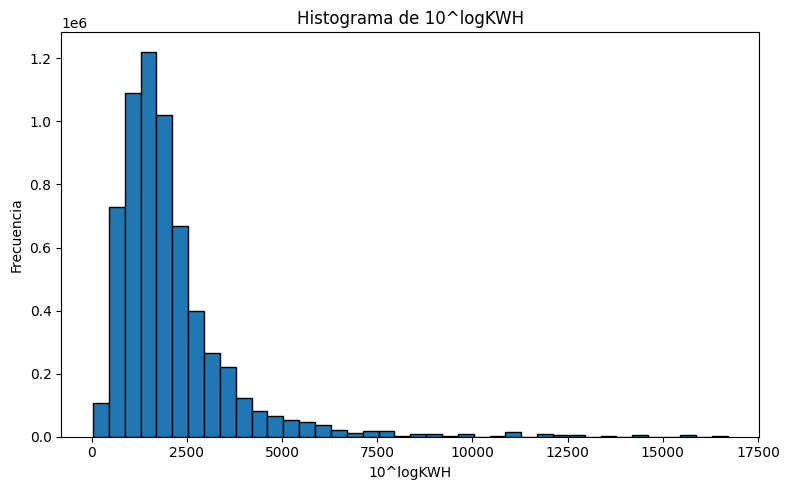

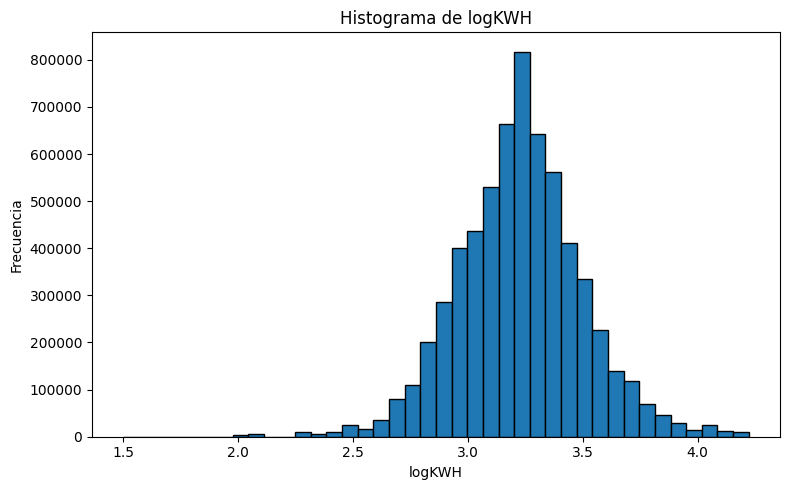

In [19]:
weighted_histogram(data=model_data, response="logKWH", weight="NWEIGHT", transform = "exp10")
weighted_histogram(data=model_data, response="logKWH", weight="NWEIGHT", transform = "none")

# PROBANDO EL LIMITE DE LOS DATOS



## EXPERIMENTO 1: OTROS MODELOS

Probando distintos modelos e hiperparámeros por validación cruzada observamos que el R2 alcanza su mayor valor alrededor del 0.16.
Eso sugiere que las variables disponibles no explican suficiente del consumo total

In [ ]:
models = {
    "Linear Regression": linear_regression,
    "Random Forest 6": random_forest_6,
    "Random Forest 8": random_forest_8,
    "Random Forest 10": random_forest_10,
    "LightGBM 0.001": lightgbm_001,
    "LightGBM 0.01": lightgbm_01,
    "LightGBM 0.05": lightgbm_05,
    "LightGBM 0.10": lightgbm_10,
}

results = cross_validation(
    data=model_data,
    kfolds=20,
    seed=1234,
    list_of_models=models,
    response="logKWH",
    weight="NWEIGHT",
)

print(results)

               Model  Median_R2
0   Random Forest 10   0.166931
1    Random Forest 8   0.166209
2    Random Forest 6   0.164665
3      LightGBM 0.01   0.151737
4  Linear Regression   0.144259
5     LightGBM 0.001   0.093140
6      LightGBM 0.05   0.092334
7      LightGBM 0.10  -0.003133


In [48]:
np.percentile( ( 10**(model_data['LAVARROPAS_frecuencia_log']) -1), 99)


np.float64(15.0)

In [49]:
( 10**(model_data['LAVARROPAS_frecuencia_log']) -1).median()

3.0

In [6]:
import pandas as pd
aux ={}
pd.isna( aux["cosa"] )

KeyError: 'cosa'

## EXPERIMENTO 2: LAS CATEGORÍAS DE CONSUMO

Se analizaron las distintas categorías de consumo. Debido a que no todos los hogares podían tener todas las categorías (ejemplo: solo los hogares con aire acondicionado pueden tener consumo de aire acondicionado) se decidió tener en cuenta dos métricas:

Porcentaje de hogares con consumo (eje x): Es decir aquellos hogares donde existe al menos un kwh de consumo. Idealmente este número esta cerca del 50% para poder discriminar los hogares.

Consumo promedio, para los hogares con consumo (eje Y): Mide el impacto de la categoría conciderando hogares con al menos un kwh de consumo. Los mejores predictores poseen mayor valor en esta dimensión.

Observando el gráfico vemos que las categorías de mayor impacto: calefacción, aire acondicionado, piscina, agua caliente solo están presentes en unos pocos hogares.
Otros gastos importantes como lo son TV, luces y refrigeradores están presentes en todos los hogares.

Esta falta de variabilidad explica la falta de poder predictivo del modelo: los principales factores del consumo de los hogares son constantes.

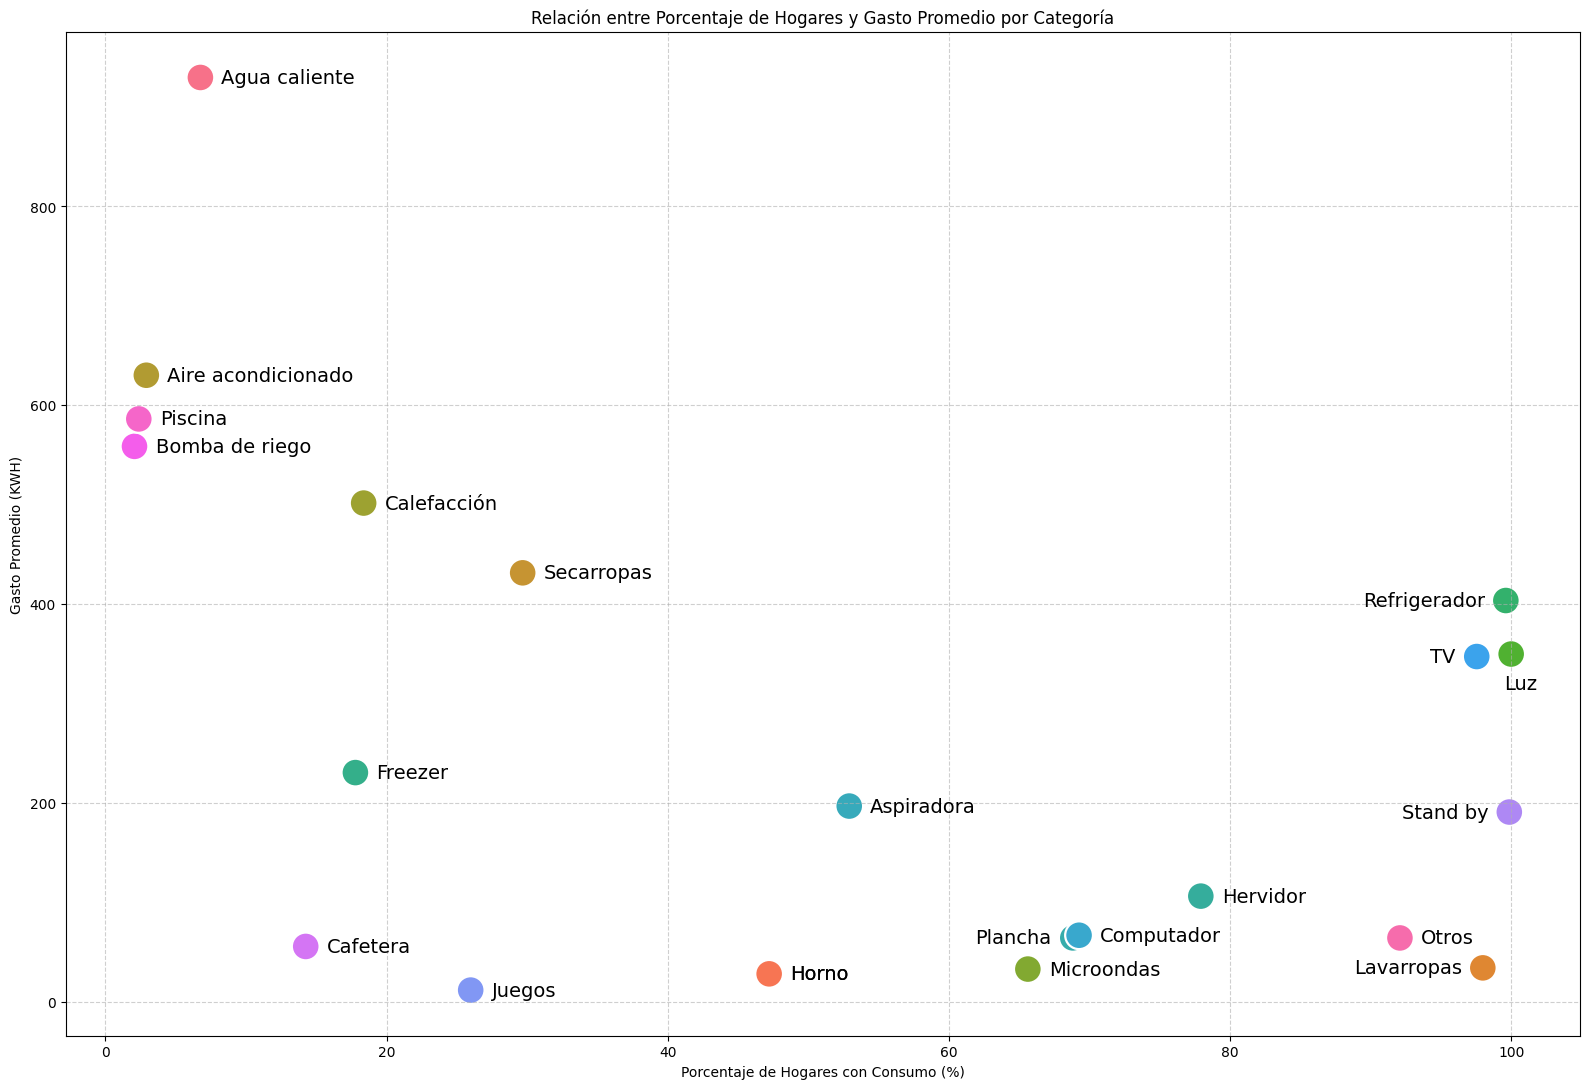

In [ ]:
## Porcentaje de hogares con gasto en un area vs gasto promedio cuanto hay gasto
aux = data.copy()
aux['Calefacción'] = data[['Calefacción Central Elec','Calefactores Elec'] ].sum(axis=1)
aux['Agua caliente'] = data[['Ducha Elec' ,'Tina Elec', 'Lavado loza Elec']].sum(axis=1)
aux['Aire acondicionado'] = data['A/C Electricidad']
aux['Secarropas'] = data['Secado Ropa Elec']
aux['Lavarropas'] = data['Lavado Ropa Elec']

aux['Microondas'] = data['Microondas Electricidad']
aux['Horno'] = data['Hornillo elec. Electricidad']
aux['Luz'] = data['Iluminación Electricidad']
aux['Refrigerador'] = data['Refrigerador Electricidad']
aux['Freezer'] = data['Freezer Electricidad']
aux['Hervidor'] = data['Hervidor Electricidad']
aux['Plancha'] = data['Plancha Electricidad']
aux['Aspiradora'] = data['Aspiradora Electricidad']
aux['Computador'] = data['Computador Electricidad']
aux['TV'] = data['TV Electricidad']
aux['Juegos'] = data['Juegos Electricidad']
aux['Stand by'] = data['Stand by Electricidad']
aux['Cafetera'] = data['Cafetera Electricidad']
aux['Bomba de riego'] = data['Bomba de riego Electricidad']
aux['Piscina'] = data['Piscina Electricidad']
aux['Otros'] = data['Otros Electricidad']


vars_consumo= ['Agua caliente', 'Horno' ,
               'Lavarropas', 'Secarropas',
               'Aire acondicionado',
       'Calefacción',  'Microondas',
       'Horno','Luz',
       'Refrigerador','Freezer','Hervidor',
       'Plancha','Aspiradora','Computador',
       'TV','Juegos','Stand by',
       'Cafetera','Bomba de riego','Piscina','Otros',]

aux_2 = pd.DataFrame({"categoria": vars_consumo})

total = data['FE'].sum()

for var in vars_consumo:
  aux_2.loc[aux_2["categoria"] == var, "porcentaje"] = aux.loc[aux[var]>0, 'FE'].sum() *100/ total
  aux_2.loc[aux_2["categoria"] == var, "gasto_promedio"] = aux.loc[aux[var]>0, var].sum() / aux.loc[aux[var]>0, 'FE'].sum()


plt.figure(figsize=(16, 11)) # Increased figure size
sns.scatterplot(data=aux_2, x='porcentaje', y='gasto_promedio', hue='categoria', s=400, legend=False)

for i, row in aux_2.iterrows():
    # Adjust text position for specific categories to avoid overlap
    if row['categoria'] in ['Plancha', 'TV', 'Refrigerador', 'Stand by', 'Lavarropas']:
        plt.text(row['porcentaje'] - 1.5, row['gasto_promedio'], row['categoria'], ha='right', va='center', fontsize=14)
    elif row['categoria'] in ['Luz']:
        plt.text(row['porcentaje'] - 0.5, row['gasto_promedio']-30, row['categoria'], ha='left', va='center', fontsize=14)
    else:
        plt.text(row['porcentaje'] + 1.5, row['gasto_promedio'], row['categoria'], ha='left', va='center', fontsize=14)

plt.title('Relación entre Porcentaje de Hogares y Gasto Promedio por Categoría')
plt.xlabel('Porcentaje de Hogares con Consumo (%)')
plt.ylabel('Gasto Promedio (KWH)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## EXPERIMENTO 3: OTRAS VARIABLES

Se aplica un modelo de random forest sobre la totalidad de la base. Esto incluye todas las variable no concideradas (excepto las asociadas al valor de la boleta). El modelo obtiene consistentemente un R2 de 0.15 en los datos de prueba y alrededor de 0.25 en los datos de entrenamiento (distintos conjuntos de hiperparámetros no pudieron solucionar esto).

Se concluye que el mejor de los modelos obtendrá un R2 de entre 0.15 y 0.20 para predecir el logaritmo del consumo


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, median_absolute_error, mean_squared_error

# -------------------------------------------------
# 1. Prepare data
# -------------------------------------------------
aux = data.copy()
vars = [	'F1',	'F2',	'P1',	'P2',	'P3_A',	'P3_B',	'P4',	'P5',	'P6',	'P7',	'P8_A',	'P8_B',	'P8_Otro',	'P9_A',	'P9_B',	'P10_A_Pequeño',	'P10_A_Mediano',	'P10_A_Grande',	'P10_B_Pequeño',	'P10_B_Mediano',	'P10_B_Grande',	'P11_A',	'P11_B',	'P11_C',	'P11_D',	'P11_E',	'P11_E_Otro',	'P12',	'P13',	'P13.1',	'P14_A',	'P14_B',	'P15',	'P18',	'P19',	'P20',	'P21',	'P22',	'P23_Consumo',	'P24_Consumo_Verano',	'P24_Consumo_Invierno',	'P25',	'P26',	'P27',	'P28_Consumo',	'P29_Consumo_Verano',	'P29_Consumo_Invierno',	'P30',	'P31_Invierno_5kg_Cantidad ',	'P31_Invierno_5kg_Frecuencia',	'P31_Invierno_5kg_Gasto',	'P31_Invierno_11kg_Cantidad ',	'P31_Invierno_11kg_Frecuencia',	'P31_Invierno_11kg_Gasto',	'P31_Invierno_15kg_Cantidad ',	'P31_Invierno_15kg_Frecuencia',	'P31_Invierno_15kg_Gasto',	'P31_Invierno_45kg_Cantidad ',	'P31_Invierno_45kg_Frecuencia',	'P31_Invierno_45kg_Gasto',	'P31_Verano_5kg_Cantidad ',	'P31_Verano_5kg_Frecuencia',	'P31_Verano_5kg_Gasto',	'P31_Verano_11kg_Cantidad ',	'P31_Verano_11kg_Frecuencia',	'P31_Verano_11kg_Gasto',	'P31_Verano_15kg_Cantidad ',	'P31_Verano_15kg_Frecuencia',	'P31_Verano_15kg_Gasto',	'P31_Verano_45kg_Cantidad ',	'P31_Verano_45kg_Frecuencia',	'P31_Verano_45kg_Gasto',	'P32',	'P33.1_A',	'P33.1_A_veces',	'P33.1_A_mes',	'P33.1_B',	'P33.2_A',	'P33.2_A_veces',	'P33.2_A_mes',	'P33.2_B',	'P34',	'P35',	'P36_UN1_A',	'P36_UN1_B',	'P36_UN1_C',	'P36_UN2_A',	'P36_UN2_B',	'P36_UN2_C',	'P37',	'P38',	'P39_A',	'P39_B',	'P39_C',	'P39_D',	'P39_E',	'P39_F',	'P39_G',	'P39_H',	'P39_I',	'P39_J',	'P39_K',	'P39_L',	'P39_M',	'P39_M_Otro',	'P40_A',	'P40_A_Otro',	'P40_B',	'P40_B_Otro',	'P41_A',	'P41_B',	'P41_C',	'P41_D',	'P41_E',	'P41_F',	'P41_F_Otro',	'P42',	'P42.1',	'P43',	'P44',	'P45',	'P46',	'P47',	'P48',	'P49',	'P50',	'P51_A',	'P51_B',	'P51_C',	'P51_D',	'P51_E',	'P51_F',	'P51_F_Otro',	'P52_A',	'P52_B',	'P53',	'P54',	'P54_Otro',	'P55_Verano',	'P55_Invierno',	'P56',	'P57_Verano',	'P57_Invierno',	'P58',	'P59_Verano',	'P59_Invierno',	'P60',	'P61',	'P61.1_Otro',	'P62',	'P63_Kilos',	'P63_Gasto',	'P64_Kilos',	'P64_Gasto',	'P65',	'P66',	'P67',	'P67.1_Otro',	'P68',	'P69',	'P70_Ene',	'P70_Feb',	'P70_Mar',	'P70_Abr',	'P70_May',	'P70_Jun',	'P70_Jul',	'P70_Ago',	'P70_Sep',	'P70_Oct',	'P70_Nov',	'P70_Dic',	'P71_Horas_Ene',	'P71_Horas_Feb',	'P71_Horas_Mar',	'P71_Horas_Abr',	'P71_Horas_May',	'P71_Horas_Jun',	'P71_Horas_Jul',	'P71_Horas_Ago',	'P71_Horas_Sep',	'P71_Horas_Oct',	'P71_Horas_Nov',	'P71_Horas_Dic',	'P72',	'P72.1',	'P73',	'P74',	'P75_Ene',	'P75_Feb',	'P75_Mar',	'P75_Abr',	'P75_May',	'P75_Jun',	'P75_Jul',	'P75_Ago',	'P75_Sep',	'P75_Oct',	'P75_Nov',	'P75_Dic',	'P76_Horas_Ene',	'P76_Horas_Feb',	'P76_Horas_Mar',	'P76_Horas_Abr',	'P76_Horas_May',	'P76_Horas_Jun',	'P76_Horas_Jul',	'P76_Horas_Ago',	'P76_Horas_Sep',	'P76_Horas_Oct',	'P76_Horas_Nov',	'P76_Horas_Dic',	'P77',	'P78',	'P78.1',	'P79',	'P79.1',	'P79.2',	'P80',	'P80.1',	'P81_Ene',	'P81_Feb',	'P81_Mar',	'P81_Abr',	'P81_May',	'P81_Jun',	'P81_Jul',	'P81_Ago',	'P81_Sep',	'P81_Oct',	'P81_Nov',	'P81_Dic',	'P82_Horas_Ene',	'P82_Horas_Feb',	'P82_Horas_Mar',	'P82_Horas_Abr',	'P82_Horas_May',	'P82_Horas_Jun',	'P82_Horas_Jul',	'P82_Horas_Ago',	'P82_Horas_Sep',	'P82_Horas_Oct',	'P82_Horas_Nov',	'P82_Horas_Dic',	'P83',	'P84',	'P85',	'P86',	'P87',	'P88',	'P89_Equipo1',	'P89_Equipo2',	'P89_Equipo3',	'P90_Etiqueta_Equipo1',	'P90_Etiqueta_Equipo2',	'P90_Etiqueta_Equipo3',	'P91_Ene',	'P91_Feb',	'P91_Mar',	'P91_Abr',	'P91_May',	'P91_Jun',	'P91_Jul',	'P91_Ago',	'P91_Sep',	'P91_Oct',	'P91_Nov',	'P91_Dic',	'P92_Horas_Ene',	'P92_Horas_Feb',	'P92_Horas_Mar',	'P92_Horas_Abr',	'P92_Horas_May',	'P92_Horas_Jun',	'P92_Horas_Jul',	'P92_Horas_Ago',	'P92_Horas_Sep',	'P92_Horas_Oct',	'P92_Horas_Nov',	'P92_Horas_Dic',	'P93_Living_A',	'P93_Living_B1',	'P93_Living_B2',	'P93_Living_B3',	'P93_Living_B4',	'P93_Living_B5',	'P93_Living_B6',	'P93_Living_99',	'P93_Living_C',	'P93_Comedor_A',	'P93_Comedor_B1',	'P93_Comedor_B2',	'P93_Comedor_B3',	'P93_Comedor_B4',	'P93_Comedor_B5',	'P93_Comedor_B6',	'P93_Comedor_99',	'P93_Comedor_C',	'P93_Cocina_A',	'P93_Cocina_B1',	'P93_Cocina_B2',	'P93_Cocina_B3',	'P93_Cocina_B4',	'P93_Cocina_B5',	'P93_Cocina_B6',	'P93_Cocina_99',	'P93_Cocina_C',	'P93_Baños_A',	'P93_Baños_B1',	'P93_Baños_B2',	'P93_Baños_B3',	'P93_Baños_B4',	'P93_Baños_B5',	'P93_Baños_B6',	'P93_Baños_99',	'P93_Baños_C',	'P93_Dormitorios_A',	'P93_Dormitorios_B1',	'P93_Dormitorios_B2',	'P93_Dormitorios_B3',	'P93_Dormitorios_B4',	'P93_Dormitorios_B5',	'P93_Dormitorios_B6',	'P93_Dormitorios_99',	'P93_Dormitorios_C',	'P93_Pasillos_A',	'P93_Pasillos_B1',	'P93_Pasillos_B2',	'P93_Pasillos_B3',	'P93_Pasillos_B4',	'P93_Pasillos_B5',	'P93_Pasillos_B6',	'P93_Pasillos_99',	'P93_Pasillos_C',	'P93_Patios_A',	'P93_Patios_B1',	'P93_Patios_B2',	'P93_Patios_B3',	'P93_Patios_B4',	'P93_Patios_B5',	'P93_Patios_B6',	'P93_Patios_99',	'P93_Patios_C',	'P94',	'P95.1_A_Tipo',	'P95.1_B_Calificación',	'P95.2_A_Tipo',	'P95.2_B_Calificación',	'P96',	'P97',	'P98',	'P99.1_A_Tipo',	'P99.1_B_Calificación',	'P99.2_A_Tipo',	'P99.2_B_Calificación',	'P100',	'P101',	'P102',	'P103_A_Verano',	'P103_B_Invierno',	'P104',	'P105',	'P106',	'P107_A',	'P107_B',	'P108_Veces',	'P108_Frecuencia',	'P108_veces_semana',	'P109',	'P110',	'P111',	'P112',	'P113',	'P114',	'P115',	'P116',	'P117',	'P118',	'P119',	'P120',	'P121',	'P122',	'P123',	'P124.1_A',	'P124.1_B',	'P124.1_C',	'P124.2_A',	'P124.2_B',	'P124.2_C',	'P125',	'P126_TV1_A',	'P126_TV1_B',	'P126_TV1_C',	'P126_TV1_D',	'P126_TV1_E',	'P126_TV2_A',	'P126_TV2_B',	'P126_TV2_C',	'P126_TV2_D',	'P126_TV2_E',	'P126_TV3_A',	'P126_TV3_B',	'P126_TV3_C',	'P126_TV3_D',	'P126_TV3_E',	'P126_TV4_A',	'P126_TV4_B',	'P126_TV4_C',	'P126_TV4_D',	'P126_TV4_E',	'P126_TV5_A',	'P126_TV5_B',	'P126_TV5_C',	'P126_TV5_D',	'P126_TV5_E',	'P127',	'P128',	'P129.1_A',	'P129.1_B',	'P129.2_A',	'P129.2_B',	'P129.3_A',	'P129.3_B',	'P130_1',	'P130_2',	'P130_3',	'P130_4',	'P130_5',	'P130_6',	'P130_7',	'P130_8',	'P130_9',	'P130_10',	'P130_11',	'P131',	'P132',	'P133',	'P134',	'P135',	'P136',	'P137_Largo',	'P137_Ancho',	'P137_Profundidad',	'P138',	'P139',	'P140_1',	'P140_2',	'P140_3',	'P140_4',	'P140_5',	'P140_6',	'P140_7',	'P140_8',	'P140_9',	'P140_10',	'P140_11',	'P140_12',	'P140_13',	'P140_14',	'P140_15',	'P140_16',	'P140_17',	'P141_1',	'P141_2',	'P141_3',	'P141_4',	'P142',	'P142_Otro',	'P143',	'P143_Otro',	'P144',	'P145',	'P146',	'P147',	'P148',	'P149',	'P150',	'P151_Verano',	'P151_Invierno',	'P152_Agua',	'P152_Electricidad',	'P152_GL',	'P152_GN',	'P153',	'151.1',	'151.2',	'151.3',	'151.4',	'151.5',	'P154',	'P155',	'P156',	'ZT',			'Urbano/Rural ',

]
aux['logKWH'] = model_data['logKWH']
aux = aux[vars + ['logKWH', 'FE']]

target = 'logKWH'
features = vars
weight_col = 'FE'

X = aux.drop(columns=['FE', 'logKWH'])
y = aux[target]
weights = aux[weight_col]
y = aux[target]
weights = aux[weight_col]

# Identify non-numeric columns in X and remove them
non_numeric_cols = X.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print(f"Removing non-numeric columns: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)
    # Update features list to reflect the removed columns
    features = [f for f in features if f not in non_numeric_cols]

# Optional: drop rows with missing values in the variables you will use
mask = X.notna().all(axis=1) & y.notna() & weights.notna()

X = X.fillna(0)
y = y.fillna(0)
weights = weights.fillna(0)

# -------------------------------------------------
# 2. Train / test split (stratified by weight is hard, so we just split)
# -------------------------------------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42
)

# -------------------------------------------------
# 3. Fit Random Forest with sample weights
# -------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,          # or set a limit, e.g. 15
    min_samples_leaf=30,
    max_features=30,
    n_jobs=-1,
    random_state=420
)

rf.fit(X_train, y_train, sample_weight=w_train)

# -------------------------------------------------
# 4. Evaluate R²
# -------------------------------------------------
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

r2_train = r2_score(y_train, y_pred_train, sample_weight=w_train)
r2_test  = r2_score(y_test,  y_pred_test,  sample_weight=w_test)
mad_test  = median_absolute_error(y_test,  y_pred_test,  sample_weight=w_test)


print(f"R² train (weighted): {r2_train:.4f}")
print(f"R² test  (weighted): {r2_test:.4f}")
print(f"mad test  (weighted): {mad_test:.4f}")

# -------------------------------------------------
# 5. Feature importance
# -------------------------------------------------
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

Removing non-numeric columns: ['P8_Otro', 'P11_E_Otro', 'P19', 'P21', 'P26', 'P31_Invierno_15kg_Frecuencia', 'P31_Verano_5kg_Frecuencia', 'P31_Verano_11kg_Frecuencia', 'P33.1_A', 'P33.2_A', 'P36_UN1_B', 'P36_UN2_B', 'P39_M_Otro', 'P40_A_Otro', 'P40_B_Otro', 'P41_F_Otro', 'P50', 'P51_F_Otro', 'P54_Otro', 'P61.1_Otro', 'P67.1_Otro', 'P68', 'P71_Horas_Jun', 'P72.1', 'P73', 'P78.1', 'P86', 'P89_Equipo1', 'P89_Equipo2', 'P90_Etiqueta_Equipo1', 'P90_Etiqueta_Equipo2', 'P90_Etiqueta_Equipo3', 'P108_Frecuencia', 'P142_Otro', 'P143_Otro']
R² train (weighted): 0.2749
R² test  (weighted): 0.1487
mad test  (weighted): 0.1597

Feature Importances:
                     feature  importance
                        P111    0.035583
                          ZT    0.035362
                        P110    0.026089
                          P7    0.024879
                        P119    0.023721
                        P153    0.023550
                        P116    0.021307
                        P117 

# ETAPA 3: APLICANDO EL MODELO LINEAL

Se aplica un modelo de elasticidad completa (tanto la respuesta como las variables explicativas recibieron la transformación logaritmo).

Como era de esperarse, el R2 es de 0.16 (0.14 en el experimento realizado anteriormente por validación cruzada).

El

                            WLS Regression Results                            
Dep. Variable:                 logKWH   R-squared:                       0.183
Model:                            WLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     27.75
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          3.33e-130
Time:                        22:11:05   Log-Likelihood:                -814.37
No. Observations:                3500   AIC:                             1687.
Df Residuals:                    3471   BIC:                             1865.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

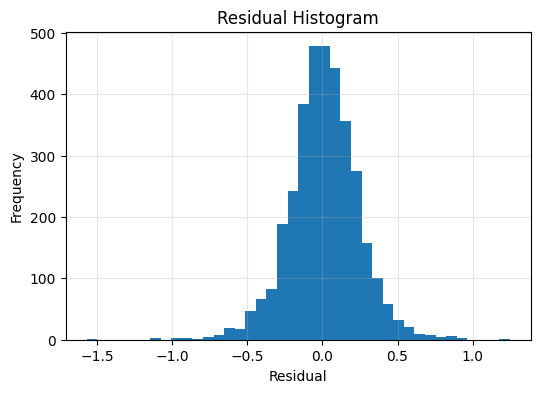

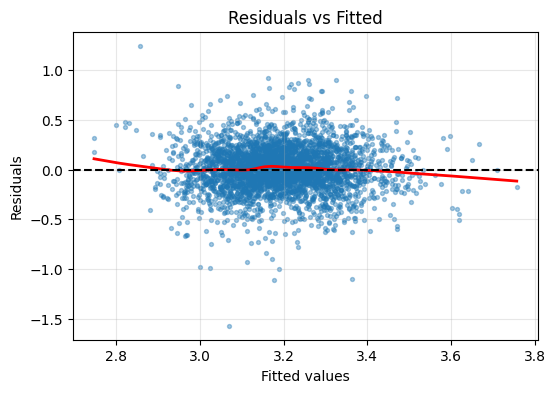

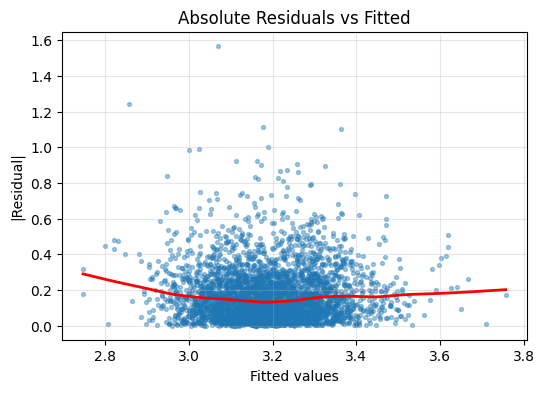

In [ ]:
aux = model_data.copy()
vars = ['VENTANAS_log', 'HABITANTES_totales_log', 'DORMITORIOS_log',
       'AGUA_CALIENTE_electrica', 'CALEFACCION_electrico',
       'SECARROPAS_electrico', 'AIRE_ACONDICIONADO', 'HORNO_electrico',
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log', 'LUCES_4_horas_log',
       'LUCES_afuera_log', 'REFRIGERADOR_log', 'FREEZER_log',
       'LAVARROPAS_frecuencia_log', 'TV_log', 'TV_frecuencia_log',
       'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
     #  'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log',
       'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
       'TV_log_X_TV_frecuencia_semana_log',
       #'LUCES_afuera_log_X_LUCES_4_horas_log',
       'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log',
       'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2', 'logKWH', 'NWEIGHT']


residual_plot(
    data=aux[vars],
    response="logKWH",
    weight="NWEIGHT",


)

                            WLS Regression Results                            
Dep. Variable:                 logKWH   R-squared:                       0.142
Model:                            WLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     38.39
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          3.69e-104
Time:                        21:55:35   Log-Likelihood:                -900.14
No. Observations:                3500   AIC:                             1832.
Df Residuals:                    3484   BIC:                             1931.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

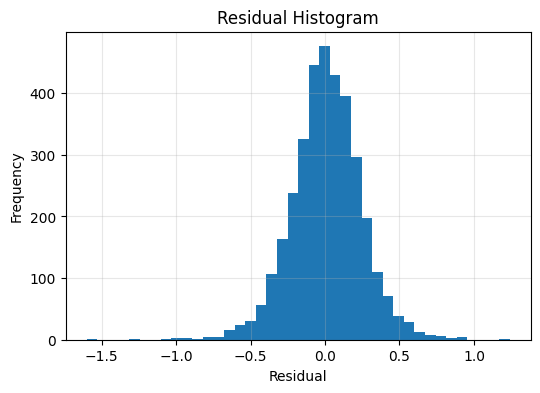

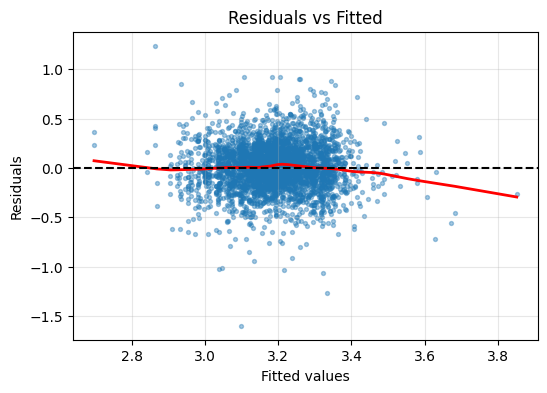

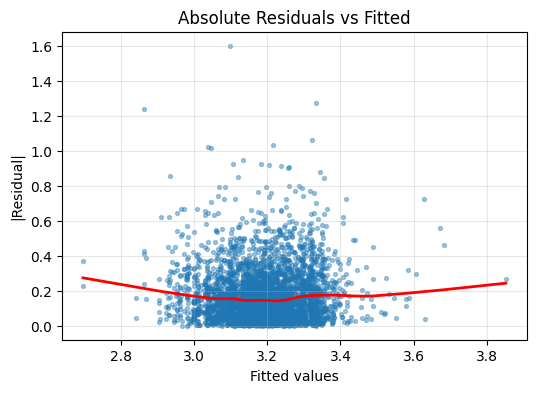

In [ ]:
#Variables base:

vars = ["logKWH", "NWEIGHT", "CALEFACCION_electrico", "AIRE_ACONDICIONADO",  "AGUA_CALIENTE_electrica",
      "VENTANAS_log", "DORMITORIOS_log",
      "CLIMA_grados_dias_calefaccion_log", "CLIMA_grados_dias_enfriamiento_log",

      "HABITANTES_totales_log",

      "AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log",
      "CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log",
      "CLIMA_grados_dias_calefaccion_log_2",
      "CLIMA_grados_dias_enfriamiento_log_2"   ,

      'VENTANAS_log_X_DORMITORIOS_log'                       ,
   #   'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'    ,
      'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log'    ,

      'DORMITORIOS_log_X_HABITANTES_totales_log'
      ]

aux = model_data[vars].copy()


residual_plot(
    data=aux,
    response="logKWH",
    weight="NWEIGHT",
)

# ETAPA 4: OTROS MODELOS

In [ ]:
model_data.columns

Index(['VENTANAS_log', 'HABITANTES_totales_log', 'DORMITORIOS_log',
       'AGUA_CALIENTE_electrica', 'CALEFACCION_electrico',
       'SECARROPAS_electrico', 'AIRE_ACONDICIONADO', 'HORNO_electrico',
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log', 'LUCES_4_horas_log',
       'LUCES_afuera_log', 'REFRIGERADOR_log', 'FREEZER_log',
       'LAVARROPAS_frecuencia_log', 'TV_log', 'TV_frecuencia_log',
       'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log',
       'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
       'TV_log_X_TV_frecuencia_semana_log',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
       'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log',
       'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_

In [ ]:
data_consumo = model_data.copy()
data_consumo['KWH'] = 10**data_consumo['logKWH']
predictores = ['VENTANAS_log', 'HABITANTES_totales_log', 'DORMITORIOS_log',
       'AGUA_CALIENTE_electrica', 'CALEFACCION_electrico',
       'SECARROPAS_electrico', 'AIRE_ACONDICIONADO', 'HORNO_electrico',
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log', 'LUCES_4_horas_log',
       'LUCES_afuera_log', 'REFRIGERADOR_log', 'FREEZER_log',
       'LAVARROPAS_frecuencia_log', 'TV_log', 'TV_frecuencia_log',
       'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log',
       'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
       'TV_log_X_TV_frecuencia_semana_log',
       'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log',
       'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log',

       'LUCES_afuera_log_X_LUCES_4_horas_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2'



               ]

vars_consumo= ['Ducha Elec' ,'Tina Elec', 'Lavado loza Elec', 'Cocina + Horno Elec' ,
               'Lavado Ropa Elec', 'Secado Ropa Elec',
       'Calefacción Central Elec','Calefactores Elec',
                   'Hornillo elec. Electricidad',
               'Iluminación Electricidad',
                'TV Electricidad'
       'Refrigerador Electricidad','Freezer Electricidad',
               'A/C Electricidad',
               'Hervidor Electricidad','Microondas Electricidad',
       'Plancha Electricidad','Aspiradora Electricidad','Computador Electricidad',
      'Juegos Electricidad','Stand by Electricidad',
       'Cafetera Electricidad','Bomba de riego Electricidad','Piscina Electricidad','Otros Electricidad',]

data_consumo['PER_AGUA_SANITARIA'] = (data['Ducha Elec'] + data['Tina Elec'] + data['Lavado loza Elec'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])
data_consumo['PER_AIRE_ACONDICIONADO'] = (data['A/C Electricidad'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])
data_consumo['PER_CALEFACCION'] = (data['Calefacción Central Elec'] +
                                   data['Calefactores Elec']  ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])

data_consumo['PER_COCINA'] = (data['Hornillo elec. Electricidad'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])

data_consumo['PER_ILUMINACION'] = (data['Iluminación Electricidad'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])

data_consumo['PER_LAVADO'] = (data['Lavado Ropa Elec']+data['Secado Ropa Elec'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])
data_consumo['PER_REFRIGERACION'] = (data['Refrigerador Electricidad']+data['Freezer Electricidad'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])
data_consumo['PER_TV'] = (data['TV Electricidad'] ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])

vars = [   'Hervidor Electricidad','Microondas Electricidad',
       'Plancha Electricidad','Aspiradora Electricidad','Computador Electricidad',
       'Juegos Electricidad','Stand by Electricidad',
       'Cafetera Electricidad','Bomba de riego Electricidad','Piscina Electricidad','Otros Electricidad']
data_consumo['PER_OTROS'] = (data[vars].sum(axis=1) ) /  (data_consumo['KWH'] * data_consumo['NWEIGHT'])


### Aguas Saniarias
Calentar agua para el lavado de plaotos, duchas, etc. Se observa una alta concencración en el valor 0, represenando aquellos que no utilizan calenadores electricos para el agua.

Se procede a eliminar a los hogares que no utilizan electricidad para calentar agua. Obeniendo un histograma asimétrico hacia la derecha.

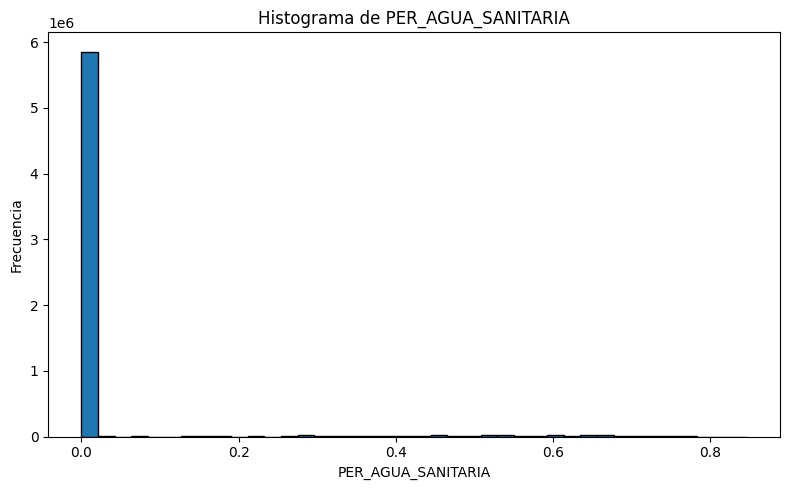

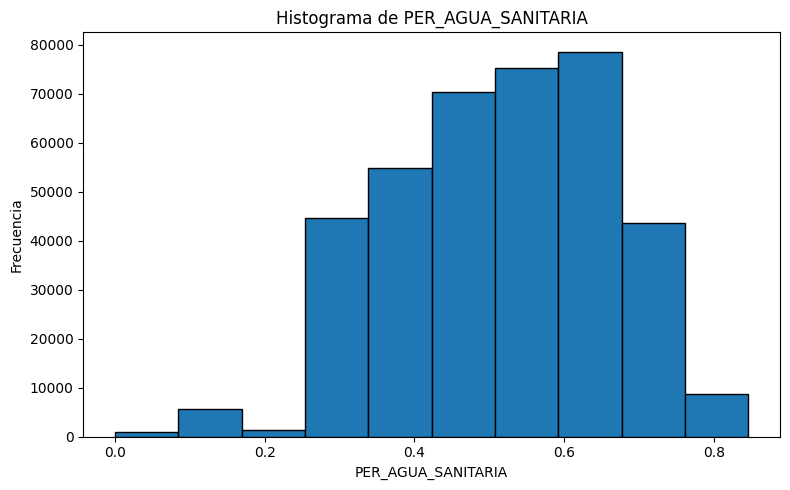

In [ ]:
weighted_histogram( data_consumo, 'PER_AGUA_SANITARIA', 'NWEIGHT')

weighted_histogram( data_consumo.loc[data_consumo['AGUA_CALIENTE_electrica']>0],
                   'PER_AGUA_SANITARIA', 'NWEIGHT', bins = 10)

Aplicamos una regresión logit solo para los hogares con agua caliente eléctrica

                            WLS Regression Results                            
Dep. Variable:     PER_AGUA_SANITARIA   R-squared:                       0.761
Model:                            WLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     25.65
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           8.87e-44
Time:                        06:32:40   Log-Likelihood:                 213.45
No. Observations:                 200   AIC:                            -380.9
Df Residuals:                     177   BIC:                            -305.0
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

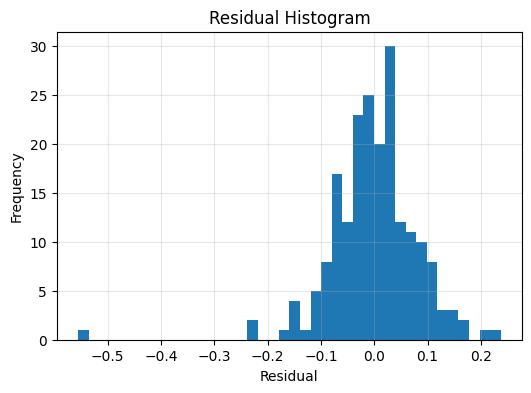

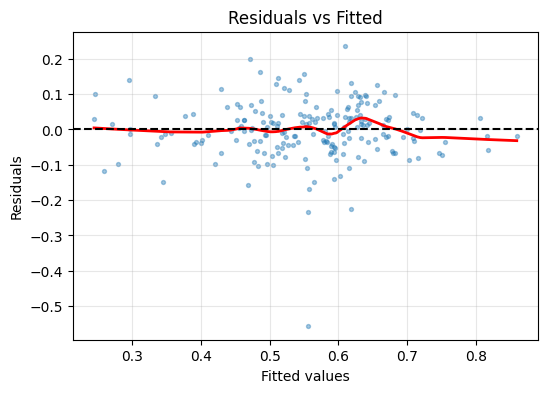

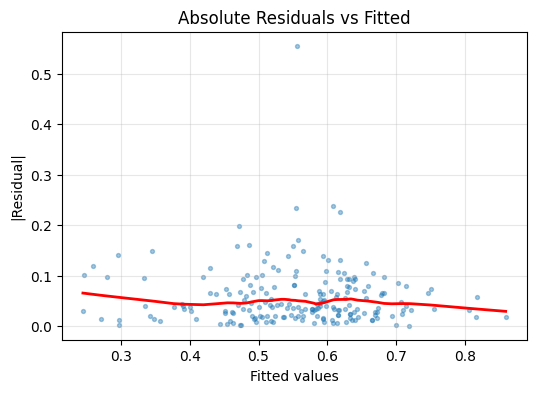

In [ ]:
target = 'PER_AGUA_SANITARIA'
filter = data_consumo['AGUA_CALIENTE_electrica']>0
residual_plot(
    data=data_consumo.loc[filter, predictores+[target, 'NWEIGHT']].drop(columns=[
        'AGUA_CALIENTE_electrica',
        'LUCES_afuera_log_X_LUCES_4_horas_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2']),
    response = target,
    weight = 'NWEIGHT'
)

### Aire Acondicionado

Nuevamene notamos la concentración de valores en cero, se decide eliminar los hogares sin aire acondicionado.
Aún así nos encontramos con hogares que no tienen gasto aire acondicionado.

Tras multiples pruebas y conciderando los pocos hogares que poseen aires acondicionados, se filtran solo los hogares que declaran tener aire acondicionado y a su vez poseen gastos en esa area.

Luego se ajusta un modelo logit.

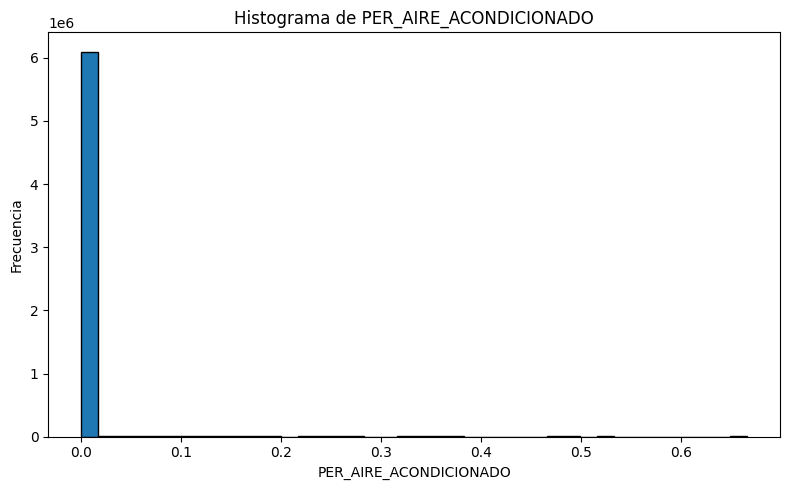

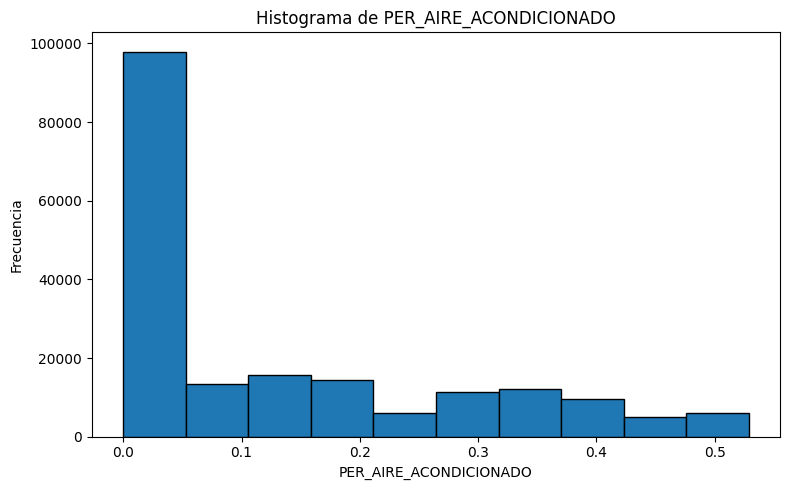

In [ ]:
weighted_histogram( data_consumo, 'PER_AIRE_ACONDICIONADO', 'NWEIGHT')

weighted_histogram( data_consumo.loc[(data_consumo['AIRE_ACONDICIONADO']>0  ) ],
                   'PER_AIRE_ACONDICIONADO', 'NWEIGHT', bins = 10)

In [ ]:
data_consumo.loc[data_consumo['PER_AIRE_ACONDICIONADO']>0, 'AIRE_ACONDICIONADO'].describe()

,AIRE_ACONDICIONADO
count,76.000000
mean,0.592105
std,0.494709
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.738
Model:                            WLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     3.089
Date:                Thu, 13 Aug 2026   Prob (F-statistic):            0.00500
Time:                        06:33:26   Log-Likelihood:                -33.109
No. Observations:                  45   AIC:                             110.2
Df Residuals:                      23   BIC:                             150.0
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

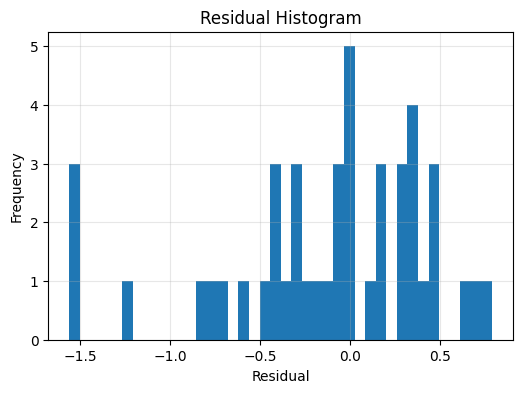

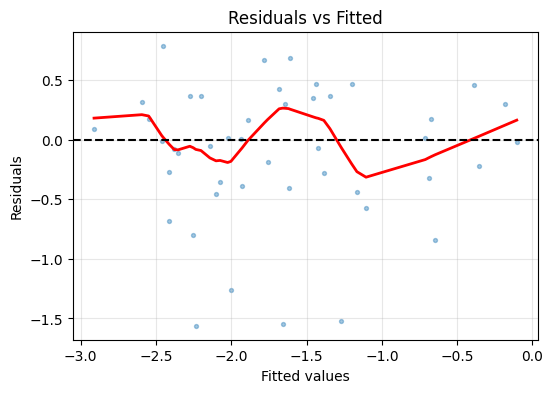

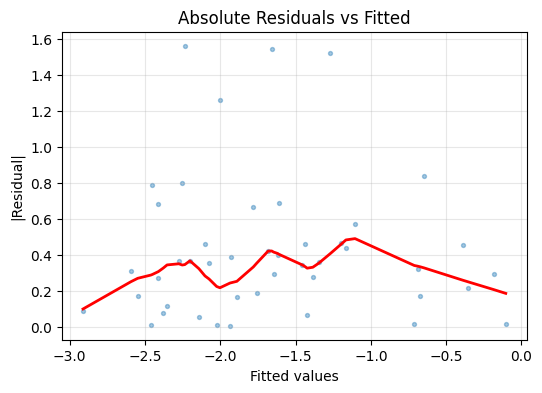

In [ ]:
target = 'PER_AIRE_ACONDICIONADO'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))

filter = (data_consumo['AIRE_ACONDICIONADO']>0) & (data_consumo['PER_AIRE_ACONDICIONADO']>0 )
residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']].drop(columns=[
        'AIRE_ACONDICIONADO', 'LUCES_afuera_log_X_LUCES_4_horas_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2' ]),
    response = 'target',
    weight = 'NWEIGHT'
)

### Calefacción

Nuevamene notamos la concentración de valores en cero, se decide eliminar los hogares sin calefacción eléctrica.

Luego se ajusta un modelo logit que parece ajustar bien.

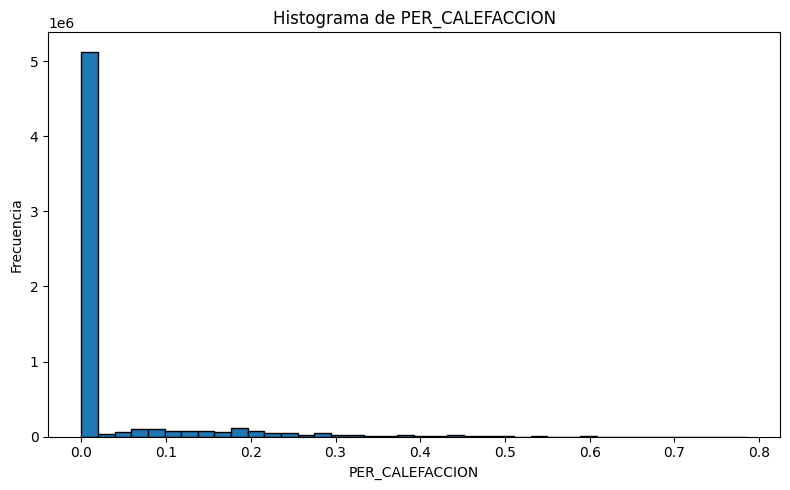

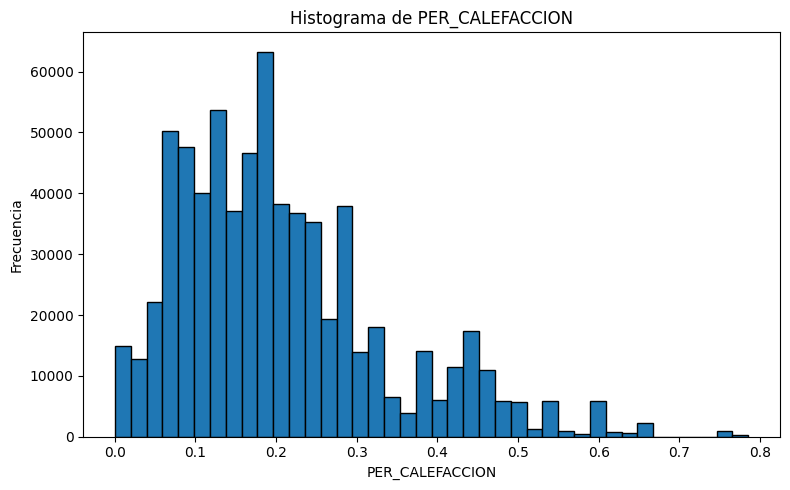

In [ ]:

filter = data_consumo['CALEFACCION_electrico']>0

weighted_histogram( data_consumo,
                   'PER_CALEFACCION', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_CALEFACCION', 'NWEIGHT')

In [ ]:
(data_consumo.loc[filter, 'PER_CALEFACCION']>0).astype(int).value_counts()

,count
PER_CALEFACCION,
0,25
1,20


In [ ]:
(data_consumo.loc[filter, 'PER_CALEFACCION']>0).astype(int).value_counts()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.425
Model:                            WLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     7.811
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           3.31e-20
Time:                        06:40:47   Log-Likelihood:                -302.52
No. Observations:                 290   AIC:                             657.0
Df Residuals:                     264   BIC:                             752.5
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

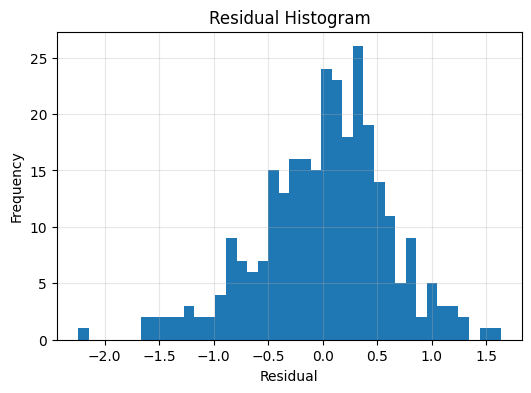

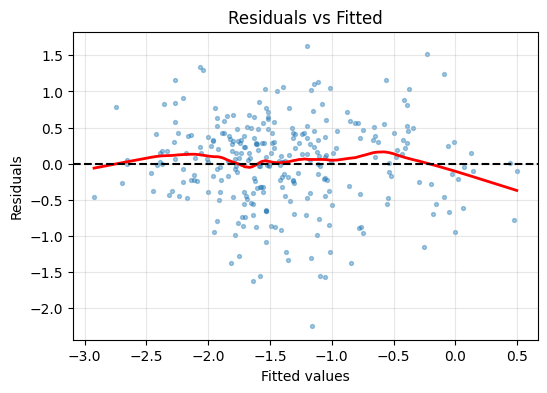

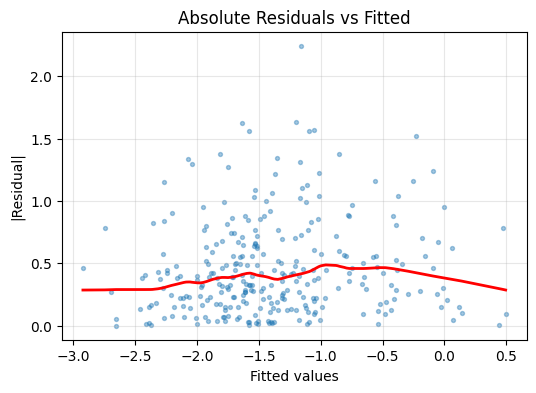

In [ ]:
target = 'PER_CALEFACCION'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
filter = (data_consumo['CALEFACCION_electrico']>0)&(data_consumo['PER_CALEFACCION']>0)
residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']].drop(columns=[
        'CALEFACCION_electrico',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
      'VENTANAS_log_X_DORMITORIOS_log',
      'DORMITORIOS_log_X_HABITANTES_totales_log',
 #     'CLIMA_grados_dias_calefaccion_log_2',
 #      'CLIMA_grados_dias_enfriamiento_log_2',
#       'TV_frecuencia_log_2',
#       'LUCES_4_horas_log_2'
    ]),
    response = 'target',
    weight = 'NWEIGHT'
)



### Cocina

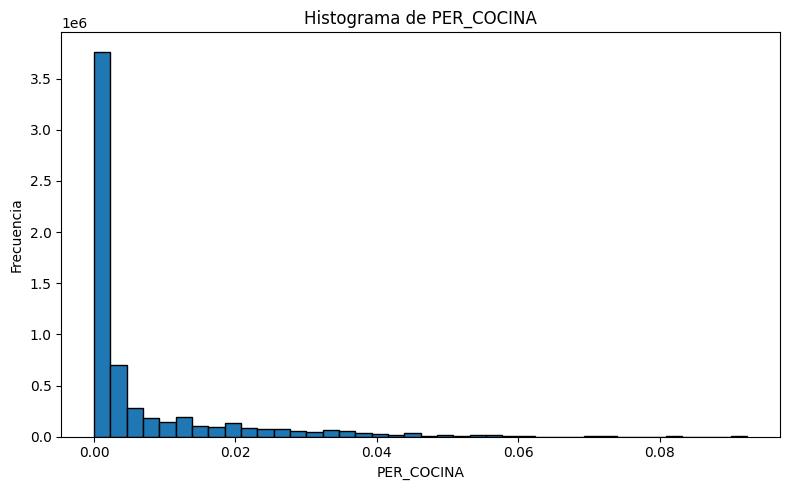

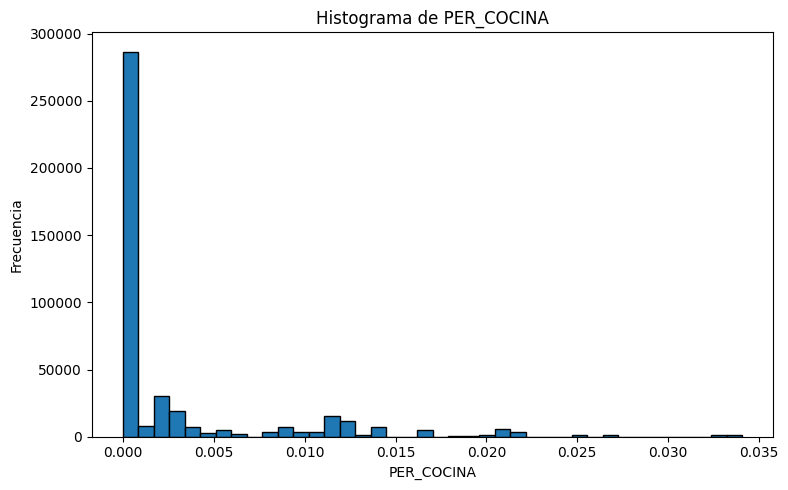

In [ ]:

filter = (data_consumo['HORNO_electrico']>0)


weighted_histogram( data_consumo,
                   'PER_COCINA', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_COCINA', 'NWEIGHT')

In [ ]:
(data_consumo.loc[filter, 'PER_COCINA']>0).astype(int).value_counts()

,count
PER_COCINA,
0,110
1,73


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.708
Model:                            WLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     5.896
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.16e-07
Time:                        06:41:41   Log-Likelihood:                -74.764
No. Observations:                  73   AIC:                             193.5
Df Residuals:                      51   BIC:                             243.9
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

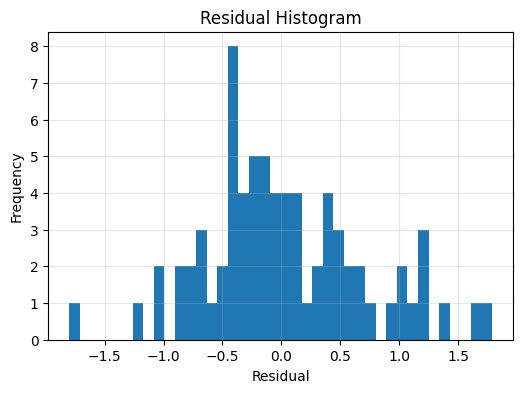

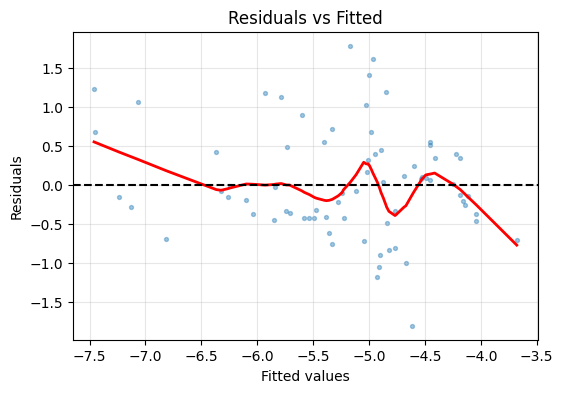

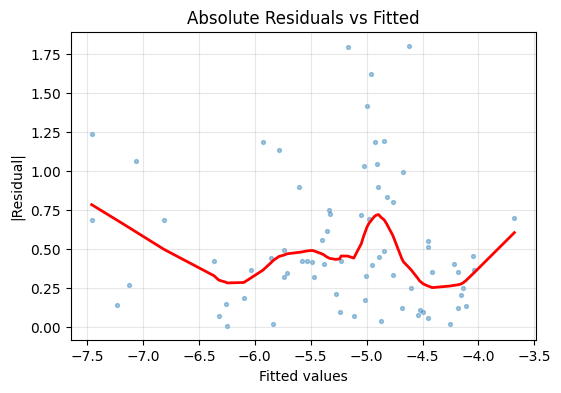

In [ ]:
target = 'PER_COCINA'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
filter = (data_consumo['HORNO_electrico']>0)&(data_consumo['PER_COCINA']>0)
residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']].drop(columns=[
        'CALEFACCION_electrico',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
      'VENTANAS_log_X_DORMITORIOS_log',
      'DORMITORIOS_log_X_HABITANTES_totales_log',
      'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2',
       'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2'
    ]),
    response = 'target',
    weight = 'NWEIGHT'
)

### Iluminación

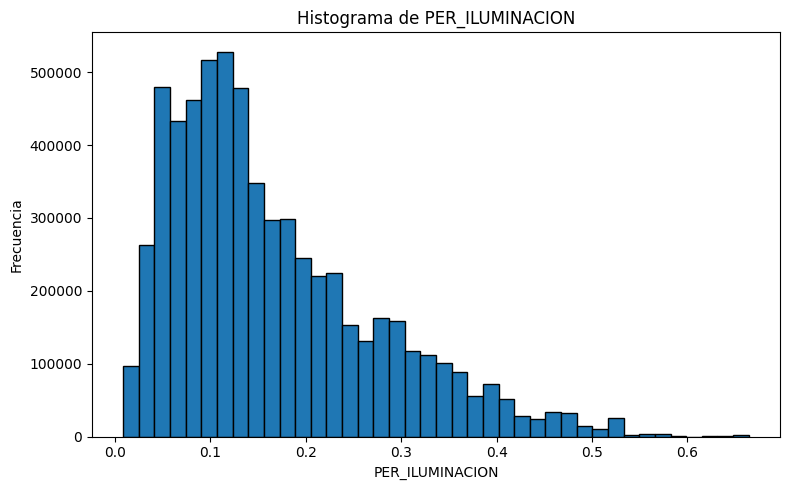

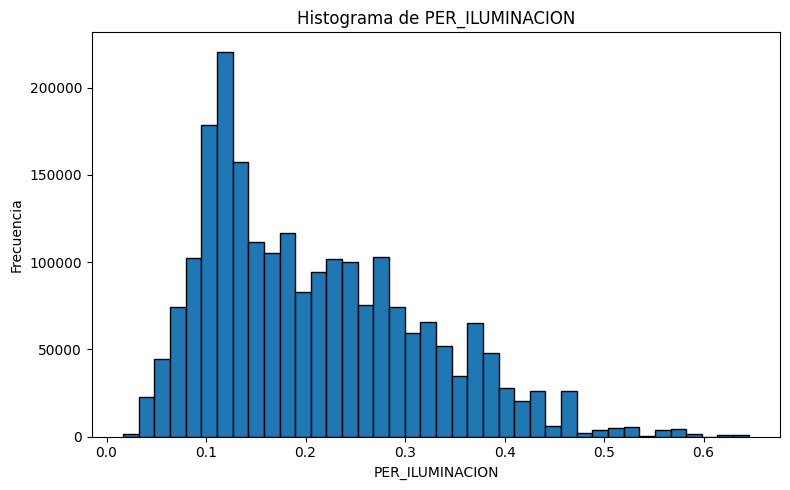

In [ ]:
filter = (data_consumo['LUCES_afuera_log']>0)& (data_consumo['LUCES_4_horas_log']>0)

weighted_histogram( data_consumo,
                   'PER_ILUMINACION', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_ILUMINACION', 'NWEIGHT')

Modelo Logit

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.763
Model:                            WLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     7.829
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.11e-09
Time:                        06:42:43   Log-Likelihood:                -59.318
No. Observations:                  73   AIC:                             162.6
Df Residuals:                      51   BIC:                             213.0
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

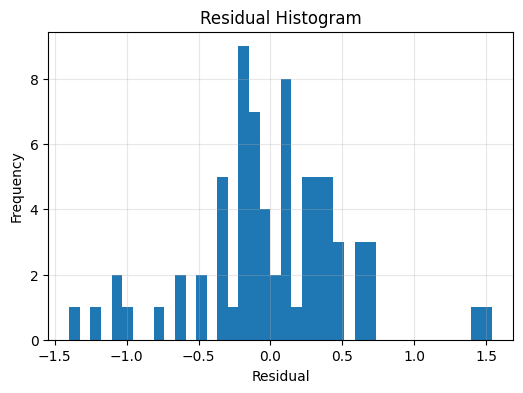

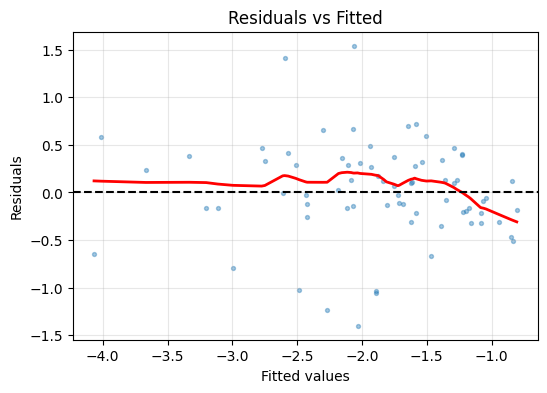

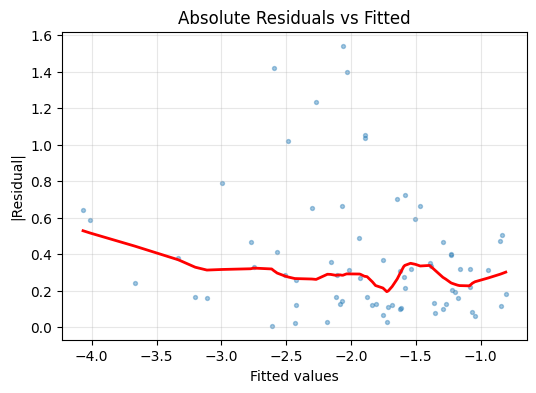

In [ ]:
target = 'PER_ILUMINACION'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']].drop(columns=[
        'CALEFACCION_electrico',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
      'VENTANAS_log_X_DORMITORIOS_log',
      'DORMITORIOS_log_X_HABITANTES_totales_log',
      'CLIMA_grados_dias_calefaccion_log_2',
      'CLIMA_grados_dias_enfriamiento_log_2',
      'TV_frecuencia_log_2',
      'LUCES_4_horas_log_2'
    ]),
    response = 'target',
    weight = 'NWEIGHT'
)

### Lavado

El principal consumo del lavado es el secarropas eléctrico. Por lo que hogares sin secarropas eléctrico presentan consumos cercanos a cero. Se los elimina.

El modelo ajusta relativamente bien con un R2 de 0.65, residuos normales y variancia constante. Parece haber un efecto cuadrático sin considerar pero el impacto es muy leve.

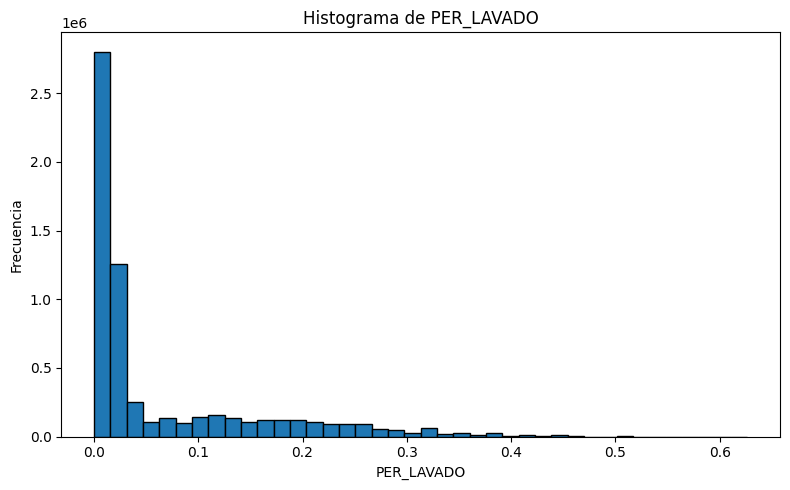

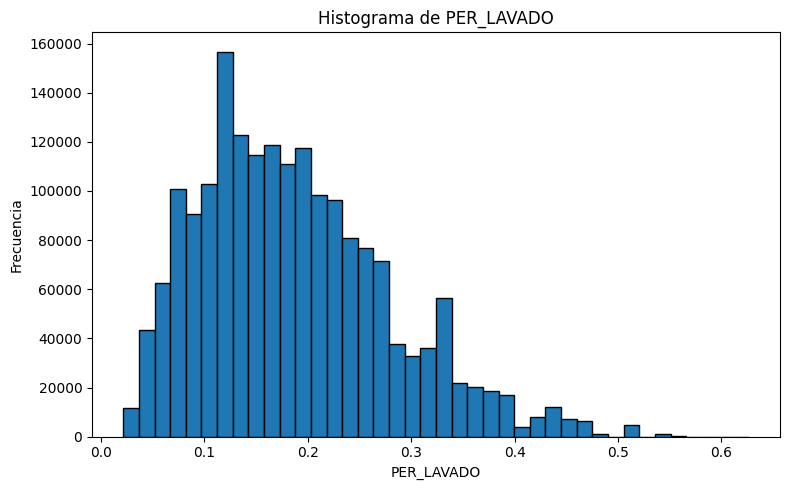

In [ ]:
filter = (data_consumo['SECARROPAS_electrico']>0)


weighted_histogram( data_consumo,
                   'PER_LAVADO', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_LAVADO', 'NWEIGHT')

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.172
Model:                            WLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     9.290
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           4.66e-27
Time:                        06:43:49   Log-Likelihood:                -1051.8
No. Observations:                 959   AIC:                             2148.
Df Residuals:                     937   BIC:                             2255.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

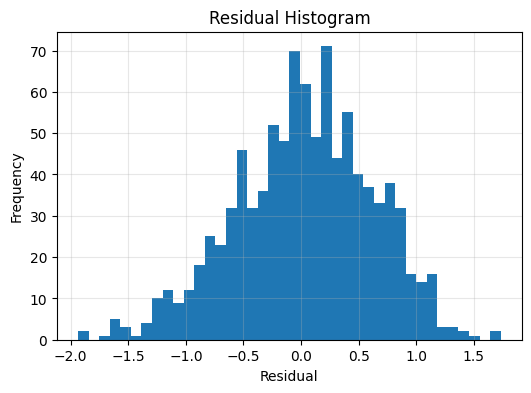

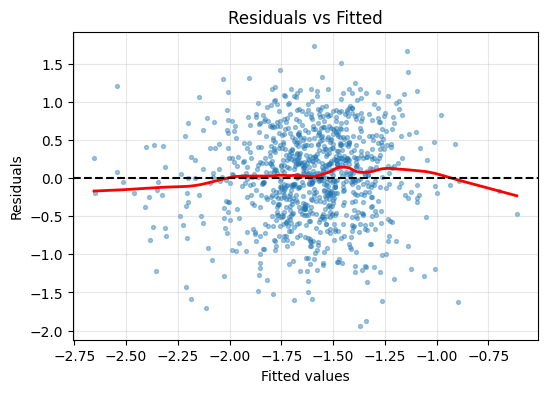

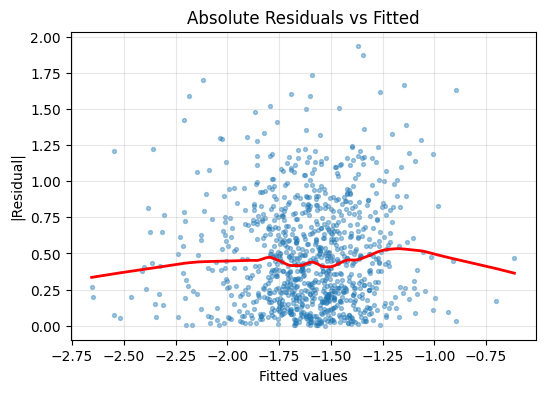

In [ ]:

target = 'PER_LAVADO'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
filter = (data_consumo['SECARROPAS_electrico']>0)

residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']].drop(columns=[
        'SECARROPAS_electrico',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
      'VENTANAS_log_X_DORMITORIOS_log',
      'DORMITORIOS_log_X_HABITANTES_totales_log',
      'CLIMA_grados_dias_calefaccion_log_2',
      'CLIMA_grados_dias_enfriamiento_log_2',
      'TV_frecuencia_log_2',
      'LUCES_4_horas_log_2'
    ]),
    response = 'target',
    weight = 'NWEIGHT'
)

### Refrigeracion

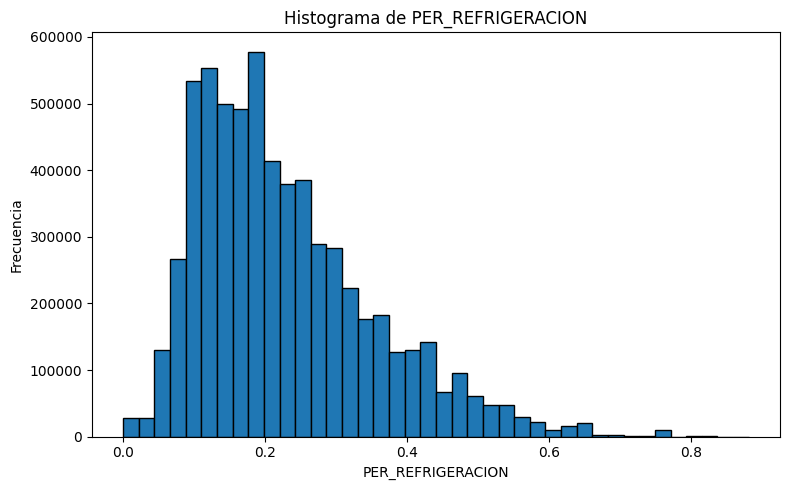

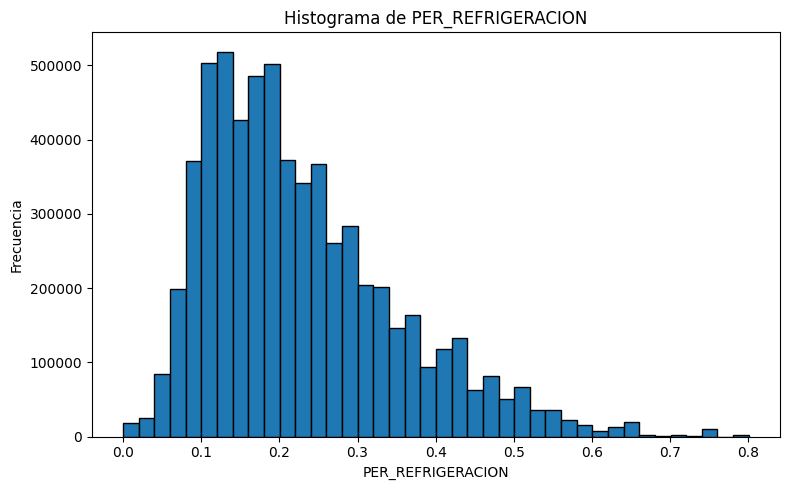

In [ ]:
filter = (data_consumo['REFRIGERADOR_log']>0)|(data_consumo['FREEZER_log']>0)


weighted_histogram( data_consumo,
                   'PER_REFRIGERACION', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_REFRIGERACION', 'NWEIGHT')

In [ ]:
filter = (data_consumo['REFRIGERADOR_log']>0)|(data_consumo['FREEZER_log']>0)

data_consumo.loc[filter, 'PER_REFRIGERACION'].describe()
(data_consumo.loc[filter, 'PER_REFRIGERACION']>0).astype(int).value_counts()

,count
PER_REFRIGERACION,
1,3458
0,20


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.483
Model:                            WLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     114.2
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:06:43   Log-Likelihood:                -3369.4
No. Observations:                3458   AIC:                             6797.
Df Residuals:                    3429   BIC:                             6975.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

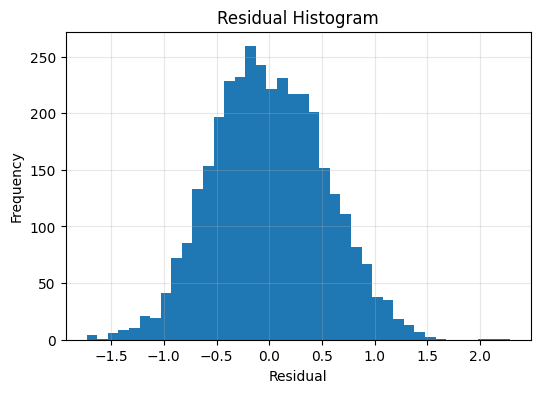

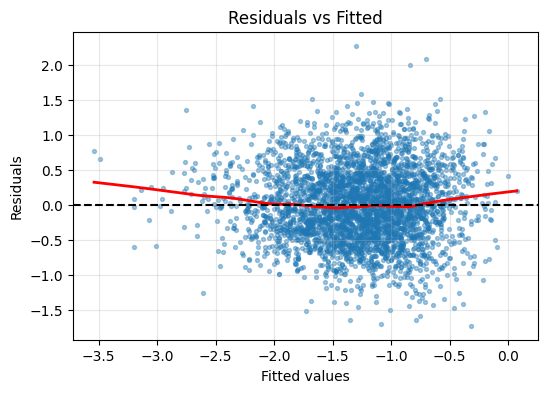

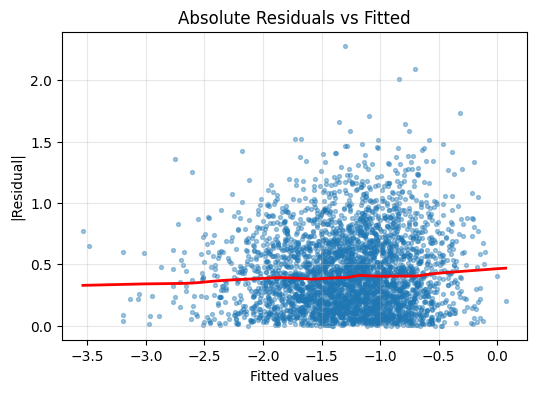

In [ ]:
filter = ((data_consumo['REFRIGERADOR_log']>0)|(data_consumo['FREEZER_log']>0)) & (data_consumo['PER_REFRIGERACION']>0)

target = 'PER_REFRIGERACION'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
data_consumo['aux'] = data_consumo['HABITANTES_totales_log']**2

residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'aux' , 'NWEIGHT']],
    response = 'target',
    weight = 'NWEIGHT'
)

### TV

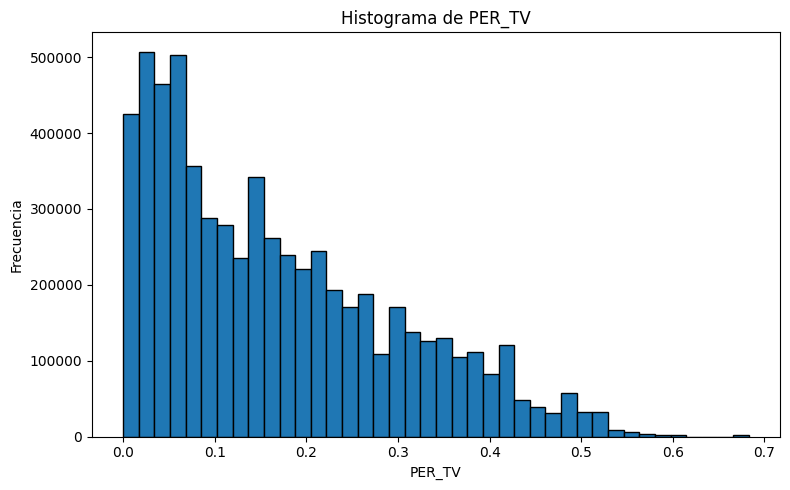

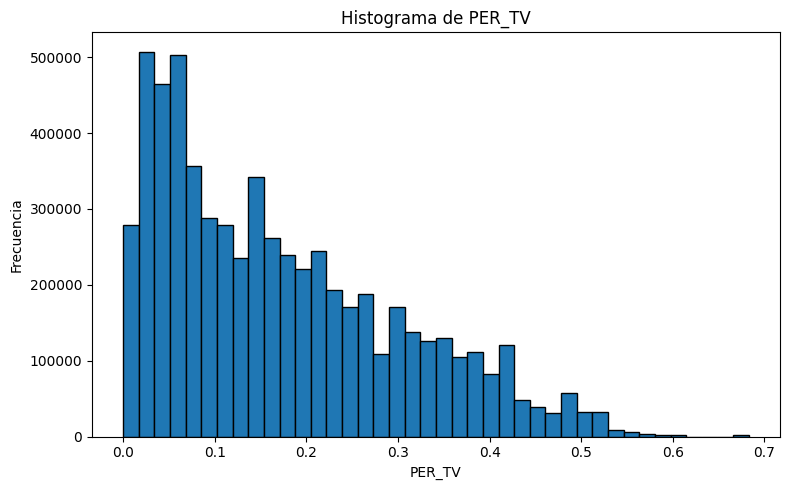

In [ ]:
filter = (data_consumo['TV_log']>0)&(data_consumo['TV_frecuencia_log']>0)


weighted_histogram( data_consumo,
                   'PER_TV', 'NWEIGHT')

weighted_histogram( data_consumo.loc[filter],
                   'PER_TV', 'NWEIGHT')

In [ ]:
filter = (data_consumo['TV_log']>0)&(data_consumo['TV_frecuencia_log']>0)

(data_consumo.loc[filter, 'PER_TV']>0).astype(int).value_counts()

,count
PER_TV,
1,3417
0,4


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.821
Model:                            WLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     555.4
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:53:15   Log-Likelihood:                -3087.8
No. Observations:                3417   AIC:                             6234.
Df Residuals:                    3388   BIC:                             6412.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

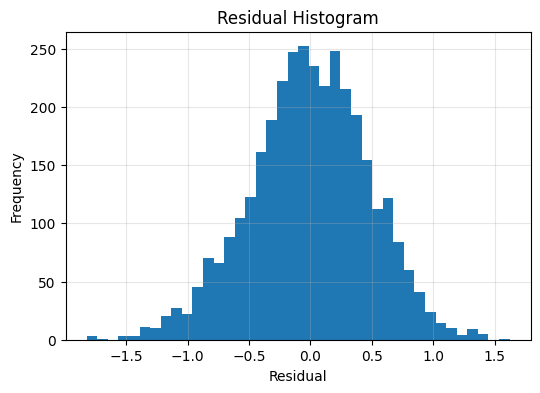

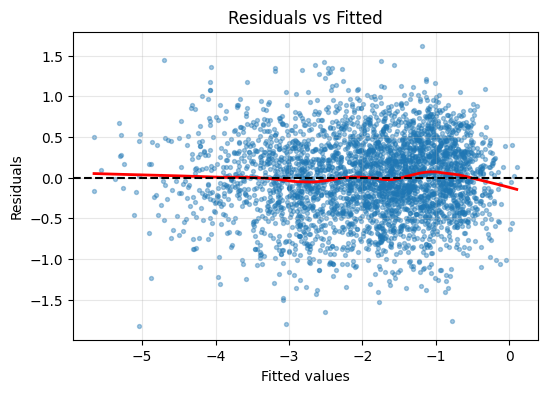

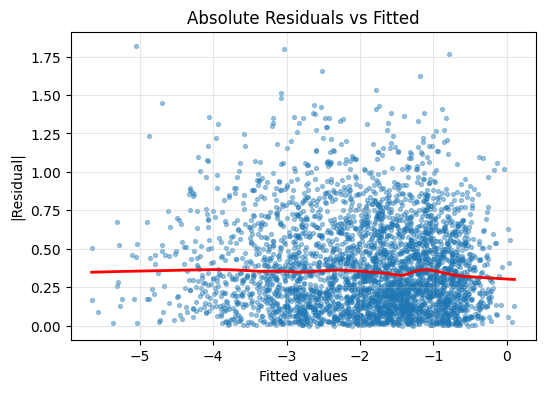

In [ ]:
target = 'PER_TV'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
filter = (data_consumo['TV_log']>0)&(data_consumo['TV_frecuencia_log']>0)&(data_consumo['PER_TV']>0)

residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'aux' , 'NWEIGHT']],
    response = 'target',
    weight = 'NWEIGHT'
)

### Otros

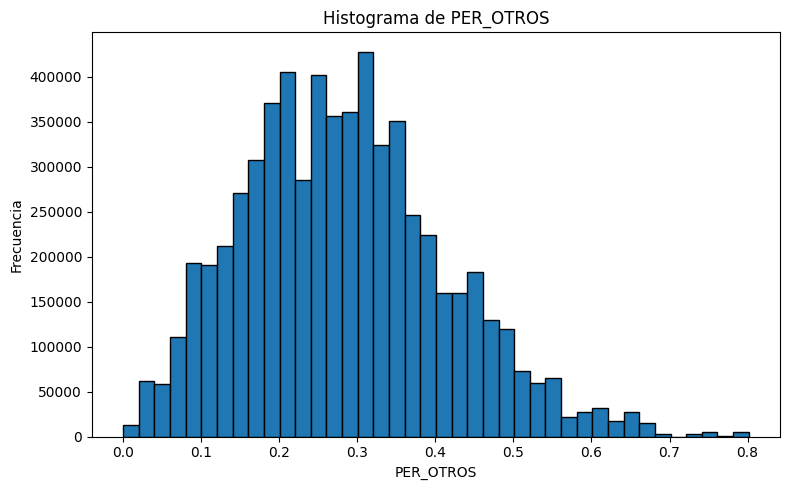

In [ ]:

weighted_histogram( data_consumo,
                   'PER_OTROS', 'NWEIGHT')

In [ ]:
(data_consumo['PER_OTROS']>0).astype(int).value_counts()

,count
PER_OTROS,
1,3495
0,5


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.339
Model:                            WLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     65.84
Date:                Wed, 12 Aug 2026   Prob (F-statistic):          6.17e-287
Time:                        23:59:38   Log-Likelihood:                -3891.1
No. Observations:                3495   AIC:                             7838.
Df Residuals:                    3467   BIC:                             8011.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

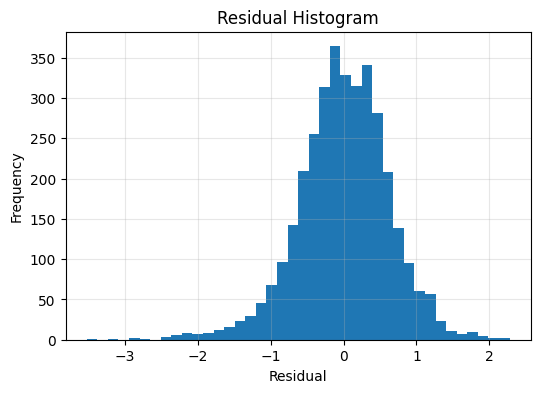

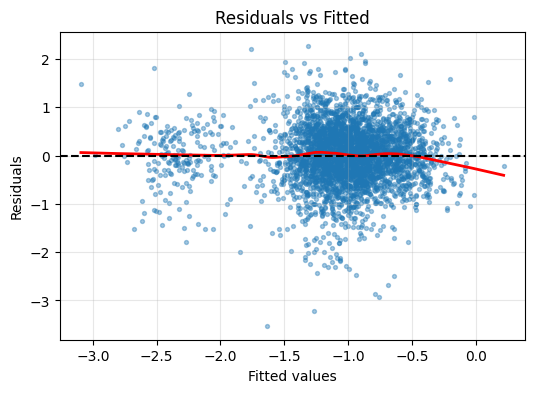

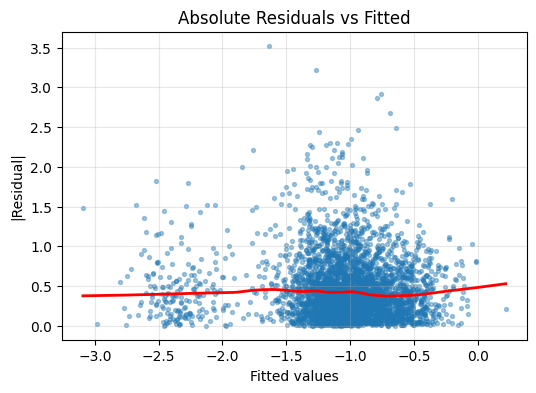

In [ ]:
target = 'PER_OTROS'
data_consumo['target'] = np.log( (data_consumo[target]) / (1-data_consumo[target]))
filter = data_consumo['PER_OTROS']>0

residual_plot(
    data=data_consumo.loc[filter, predictores+['target', 'NWEIGHT']],
    response = 'target',
    weight = 'NWEIGHT'
)

# SERiaLIzACIÓN

## MODELO BASE

In [ ]:
predictores = ["CALEFACCION_electrico",
               "AIRE_ACONDICIONADO",
               "AGUA_CALIENTE_electrica",

               "VENTANAS_log",
               "DORMITORIOS_log",
               "HABITANTES_totales_log",


               "CLIMA_grados_dias_calefaccion_log",
               "CLIMA_grados_dias_enfriamiento_log",

               "AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log",
               "CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log",
               "CLIMA_grados_dias_calefaccion_log_2",
               "CLIMA_grados_dias_enfriamiento_log_2"   ,
               'VENTANAS_log_X_DORMITORIOS_log'                       ,
               #'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'    ,
               'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log'    ,
               'DORMITORIOS_log_X_HABITANTES_totales_log'
      ]
results={}

df = model_data.copy()

# Predictors
X = df[predictores]      # list of predictor names



# assume you already have a DataFrame called df
model_info = get_model(
    df=df,
    y_col="logKWH",
    x_cols= predictores,
    weight_col="NWEIGHT",
    print_dict=True          # set to False if you don't want the print
)

model_info = 
{'coefs': {'const': -35.28135312449055,
           'CALEFACCION_electrico': -0.7849438634089401,
           'AIRE_ACONDICIONADO': 0.5332813348260148,
           'AGUA_CALIENTE_electrica': 0.02233944840823343,
           'VENTANAS_log': 0.8915352020395764,
           'DORMITORIOS_log': 1.1286927099564847,
           'HABITANTES_totales_log': 0.6943882161221977,
           'CLIMA_grados_dias_calefaccion_log': 23.370819228842834,
           'CLIMA_grados_dias_enfriamiento_log': -0.4461417276925326,
           'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log': -0.20317563962628898,
           'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log': 0.27759756806618174,
           'CLIMA_grados_dias_calefaccion_log_2': -3.6241690026815316,
           'CLIMA_grados_dias_enfriamiento_log_2': 0.2113218394637681,
           'VENTANAS_log_X_DORMITORIOS_log': -0.45814324890253655,
           'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log': -0.24739716669808576,
     

## MODELO AVANZADO

In [ ]:
predictores = ['VENTANAS_log', 'HABITANTES_totales_log', 'DORMITORIOS_log',
       'AGUA_CALIENTE_electrica', 'CALEFACCION_electrico',
       'SECARROPAS_electrico', 'AIRE_ACONDICIONADO', 'HORNO_electrico',
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log', 'LUCES_4_horas_log',
       'LUCES_afuera_log', 'REFRIGERADOR_log', 'FREEZER_log',
       'LAVARROPAS_frecuencia_log', 'TV_log', 'TV_frecuencia_log',
       'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
     #  'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log',
       'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
       'TV_log_X_TV_frecuencia_semana_log',
       #'LUCES_afuera_log_X_LUCES_4_horas_log',
       'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log',
       'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2', 'logKWH', 'NWEIGHT']



results={}

df = model_data.copy()

# Predictors
X = df[predictores]      # list of predictor names



# assume you already have a DataFrame called df
model_info = get_model(
    df=df,
    y_col="logKWH",
    x_cols= predictores,
    weight_col="NWEIGHT",
    print_dict=True          # set to False if you don't want the print
)

model_info = 
{'coefs': {'const': -3.346656285430072e-12,
           'VENTANAS_log': 5.337952302397753e-13,
           'HABITANTES_totales_log': 2.5723867480564877e-13,
           'DORMITORIOS_log': 8.881784197001252e-14,
           'AGUA_CALIENTE_electrica': 7.127631818093505e-14,
           'CALEFACCION_electrico': 1.7763568394002505e-15,
           'SECARROPAS_electrico': -4.440892098500626e-16,
           'AIRE_ACONDICIONADO': -2.9976021664879227e-14,
           'HORNO_electrico': 3.0600522116230877e-15,
           'CLIMA_grados_dias_enfriamiento_log': 1.0658141036401503e-13,
           'CLIMA_grados_dias_calefaccion_log': 1.9042545318370685e-12,
           'LUCES_4_horas_log': 1.9984014443252818e-14,
           'LUCES_afuera_log': 1.149080830487037e-14,
           'REFRIGERADOR_log': 3.6137759451548845e-14,
           'FREEZER_log': -3.894801148263127e-14,
           'LAVARROPAS_frecuencia_log': 4.3298697960381105e-15,
           'TV_log': -2.2870594307278225e-14,
           'TV_f

## MODELOS CATEGORIAS

In [ ]:
import statsmodels.api as sm
models = {"AGUA_SANITARIA": {'target' :'PER_AGUA_SANITARIA', 'filter': (data_consumo['AGUA_CALIENTE_electrica']*data_consumo['PER_AGUA_SANITARIA'])>0  },
          "AIRE_ACONDICIONADO": {'target' :'PER_AIRE_ACONDICIONADO', 'filter':(data_consumo['AIRE_ACONDICIONADO']*data_consumo['PER_AIRE_ACONDICIONADO'])>0  },
          "CALEFACCION": {'target' :'PER_CALEFACCION', 'filter': (data_consumo['CALEFACCION_electrico']*data_consumo['PER_CALEFACCION'])>0  },
          "COCINA": {'target' :'PER_COCINA', 'filter':  (data_consumo['HORNO_electrico']*data_consumo['PER_COCINA'])>0  }, # solo 8 casos que tienen cocina electrica pero sin consumo, se descartan
          "REFRIGERACION": {'target' :'PER_REFRIGERACION', 'filter': ((data_consumo['REFRIGERADOR_log']+data_consumo['FREEZER_log'])*data_consumo['PER_COCINA'])>0  },
          "LAVADO": {'target' :'PER_LAVADO', 'filter': (data_consumo['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log']*data_consumo['PER_LAVADO'])>0  },
          "ILUMINACION": {'target' :'PER_ILUMINACION', 'filter': ((data_consumo['LUCES_afuera_log']+data_consumo['LUCES_4_horas_log'])*data_consumo['PER_ILUMINACION'])>0  },
          "TV": {'target' :'PER_TV', 'filter': (data_consumo['TV_log_X_TV_frecuencia_semana_log']*data_consumo['PER_TV'])>0  },
           "OTROS": {'target' :'PER_OTROS', 'filter': data_consumo['PER_OTROS']>0  },



}

predictores = ['VENTANAS_log', 'HABITANTES_totales_log', 'DORMITORIOS_log',
       'AGUA_CALIENTE_electrica', 'CALEFACCION_electrico',
       'SECARROPAS_electrico', 'AIRE_ACONDICIONADO', 'HORNO_electrico',
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log', 'LUCES_4_horas_log',
       'LUCES_afuera_log', 'REFRIGERADOR_log', 'FREEZER_log',
       'LAVARROPAS_frecuencia_log', 'TV_log', 'TV_frecuencia_log',
       'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log',
       'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log',
       'TV_log_X_TV_frecuencia_semana_log',
       'LUCES_afuera_log_X_LUCES_4_horas_log',
       'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log',
       'VENTANAS_log_X_CLIMA_grados_dias_enfriamiento_log',
       'VENTANAS_log_X_DORMITORIOS_log',
       'DORMITORIOS_log_X_HABITANTES_totales_log',
       'CLIMA_grados_dias_calefaccion_log_2',
       'CLIMA_grados_dias_enfriamiento_log_2', 'TV_frecuencia_log_2',
       'LUCES_4_horas_log_2',]


results = {}

for name, info in models.items():

    # Filter data
    df = data_consumo.loc[info["filter"]].copy()

    # Response
    y = df[info["target"]]

    # Predictors
    X = df[predictores]      # list of predictor names

    X = sm.add_constant(X , has_constant="add")

    # Fractional logit
    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=df["NWEIGHT"]   # optional
    )

    fit = model.fit()

    results[name] = fit.params.to_dict()

print(results)

{'AGUA_SANITARIA': {'const': 2.9265545228362866, 'VENTANAS_log': 25.32878395002117, 'HABITANTES_totales_log': 2.7765199598053414, 'DORMITORIOS_log': 0.24441729510606613, 'AGUA_CALIENTE_electrica': 2.926554522836404, 'CALEFACCION_electrico': 4.823627876105736, 'SECARROPAS_electrico': -0.15807778228575625, 'AIRE_ACONDICIONADO': -1.1863521090585194, 'HORNO_electrico': -0.24090064763763863, 'CLIMA_grados_dias_enfriamiento_log': 1.5660092582482612, 'CLIMA_grados_dias_calefaccion_log': -11.215849987040754, 'LUCES_4_horas_log': 0.36784748303059056, 'LUCES_afuera_log': -0.019964215775811395, 'REFRIGERADOR_log': 0.954348041518474, 'FREEZER_log': -0.3911003128865846, 'LAVARROPAS_frecuencia_log': -0.07858905215778389, 'TV_log': -1.4946267673478855, 'TV_frecuencia_log': 0.9587714711214312, 'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log': 0.47213131428984323, 'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log': -7.332199394807469, 'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'

In [ ]:
aux = model_data.copy()
aux['KWH'] = 10**(aux['logKWH'])
weighted_percentiles(data = aux,
value = 'KWH'                     ,
                     weight = 'NWEIGHT',
                     percentiles = [0.20, 0.40, 0.60, 0.80])

{0.2: np.float64(1018.3101050228319),
 0.4: np.float64(1465.5433158250412),
 0.6: np.float64(1918.1384039970183),
 0.8: np.float64(2706.9009915289016)}

In [ ]:
weighted_percentiles(data = aux,
value = 'KWH'                     ,
                     weight = 'NWEIGHT',
                     percentiles = [0.05, 0.10, 0.15, 0.20,
                                    0.25, 0.30, 0.35, 0.40,
                                    0.45, 0.50, 0.55, 0.60,
                                    0.65, 0.70, 0.75, 0.80,
                                    0.85, 0.90, 0.95])

{0.05: np.float64(630.1410840046804),
 0.1: np.float64(785.5160075847832),
 0.15: np.float64(895.3539188570929),
 0.2: np.float64(1018.3101050228319),
 0.25: np.float64(1140.5574892690145),
 0.3: np.float64(1270.3197308866354),
 0.35: np.float64(1369.3663954832753),
 0.4: np.float64(1465.5433158250412),
 0.45: np.float64(1592.884613209357),
 0.5: np.float64(1695.225428814099),
 0.55: np.float64(1803.8599306679796),
 0.6: np.float64(1918.1384039970183),
 0.65: np.float64(2067.653022452022),
 0.7: np.float64(2248.2859344401163),
 0.75: np.float64(2450.123356327372),
 0.8: np.float64(2706.9009915289016),
 0.85: np.float64(3086.812246463281),
 0.9: np.float64(3598.605497096215),
 0.95: np.float64(4800.1685439974135)}